# 07 — Information-Theory Audit of the β-VAE + Logistic-Regression AD Pipeline
### Version 4.1 — Final Closing Pass (Computationally Complete)

**Scope** This notebook is the information-theory-focused companion to `notebooks/04_training_qc_paper.ipynb`. Its job is to explain how AD-vs-CN information remains recoverable downstream from the saved diagnosis-agnostic β-VAE representation in `results/vae_3channels_beta65_pro`, without duplicating the broader QC material that already belongs to notebook 04.

**Pipeline bridge (important):** The encoder is trained unsupervised on a diagnosis-agnostic pool that, fold by fold, includes mapped CN + AD + MCI subjects except the held-out outer-fold CN/AD test subjects. The downstream supervised readout is trained on CN/AD only; in the saved best run it consumes latent `μ(x)` together with `Age` and `Sex`. Latent-only probes in §§5-6 therefore remain deliberate post-hoc audits of recoverable diagnostic structure, not literal restatements of the saved full classifier.

**v3 critical fix (preserved)** `test_indices.npy` contains *local pool indices* (0–182 into the AD+CN training pool), **not** global tensor indices. v3/v4.1 use `test_tensor_idx.npy` / `train_dev_tensor_idx.npy` throughout.

**v4.1 additions** Companion-scope bridge to notebook 04, pipeline cohort accounting from saved artifacts, metadata ablation (`μ` vs `Age+Sex` vs saved full pipeline), sharper score-level IT framing, and an ordered MCI VNE trend synthesis.

**Changelog** See `notebooks/07_information_theory_changelog.md` (v1→v4); this closing pass tightens scope and interpretation without turning notebook 07 into a duplicate of notebook 04.

| § | Title | Status |
|---|-------|--------|
| 0 | Configuration & run mode | always runs |
| 0b | Scope bridge to notebook 04 | markdown only |
| 1 | Dependency preflight & imports | always runs |
| 1b | Pipeline bridge & cohort accounting | from run config + fold artifacts |
| 2 | Theoretical framing | markdown only |
| 3 | Shared utilities | always runs |
| 4 | Information bottleneck audit (training history + re-inference) | requires checkpoints |
| 5 | Latent MI & confounding [**train-set only**] | requires re-inference |
| 5d | Metadata ablation (`μ` vs `Age+Sex` vs full readout) | requires re-inference + predictions |
| 6 | Top-k latent-only readout [**nested clean + per-fold uncertainty**] | requires re-inference |
| 7 | Score-level IT / MaxEnt readout [**raw vs calibrated**] | from fold predictions |
| 8 | MaxEnt / Ising scaffold [**N=183 corrected**] | requires re-inference |
| 9 | Spectral ordinal complexity proxy [**exploratory**] | requires FC tensor |
| 10 | Von Neumann entropy + MCI context | requires FC tensor |
| 10d | Ordered CN→MCI→AD VNE trend [**descriptive + ordered test**] | from FC tensor |
| 10e | Take-home message | markdown only |
| 11 | Execution report & outputs | always runs |

## §0 — Configuration

In [1]:
import os, sys, shutil
from pathlib import Path

# ── RUN MODE ────────────────────────────────────────────────────────────────
# "full_recompute"  : requires the notebook's actual execution dependencies;
#                     moves stale legacy outputs to _legacy/ before starting
# "artifact_review" : loads existing cached tables/figures; labels them explicitly;
#                     does NOT require torch/VAE re-inference dependencies
RUN_MODE = "full_recompute"   # change to "artifact_review" on restricted environments

_VALID_MODES = ("full_recompute", "artifact_review")
if RUN_MODE not in _VALID_MODES:
    raise ValueError(f"RUN_MODE must be one of {_VALID_MODES}, got {RUN_MODE!r}")

def _find_project_root(marker="pyproject.toml"):
    here = Path().resolve()
    for p in [here, *here.parents]:
        if (p / marker).exists():
            return p
    return here

PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RESULTS_DIR    = PROJECT_ROOT / "results" / "vae_3channels_beta65_pro"
DATA_DIR       = PROJECT_ROOT / "data"
OUTPUT_DIR     = RESULTS_DIR / "information_theory_output"
QC_OUTPUT_DIR  = RESULTS_DIR / "training_qc_paper_output"   # optional cross-reference only
NOTEBOOK_04    = PROJECT_ROOT / "notebooks" / "04_training_qc_paper.ipynb"
LEGACY_DIR     = OUTPUT_DIR / "_legacy"

for _d in [OUTPUT_DIR / "Figures", OUTPUT_DIR / "Tables", OUTPUT_DIR / "Logs", LEGACY_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# In full_recompute: quarantine known superseded legacy files so they don't
# appear as authoritative outputs. They are moved, not deleted.
_LEGACY_FILES = [
    "Tables/05_latent_dim_statistics.csv",
    "Tables/06_topk_auc_by_strategy.csv",
    "Tables/09_spectral_entropy_proxy.csv",
    "Tables/10_von_neumann_group_stats.csv",
]
if RUN_MODE == "full_recompute":
    for _lf in _LEGACY_FILES:
        _src = OUTPUT_DIR / _lf
        if _src.exists():
            _dst = LEGACY_DIR / _src.name
            shutil.move(str(_src), str(_dst))
            print(f"[LEGACY] moved {_src.name} -> _legacy/")

DO_TIME_SERIES  = True
DO_MAXENT       = True
DO_VON_NEUMANN  = True
DO_BETA_SWEEP   = False
SEED            = 42

N_FOLDS       = 5
LATENT_DIM    = 256
BETA_VAE      = 6.5
CHANNELS_IDX  = [1, 0, 2]
CHANNEL_NAMES = [
    "Pearson_Full_FisherZ_Signed",
    "Pearson_OMST_GCE_Signed_Weighted",
    "MI_KNN_Symmetric",
]
N_CHANNELS    = len(CHANNEL_NAMES)
IMAGE_SIZE    = 131
META_FEATURES = ["Age", "Sex"]

print(f"RUN_MODE      : {RUN_MODE}")
print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"OUTPUT_DIR    : {OUTPUT_DIR}")
print(f"QC_OUTPUT_DIR : {QC_OUTPUT_DIR}  ({'FOUND' if QC_OUTPUT_DIR.exists() else 'optional / missing'})")

RUN_MODE      : full_recompute
PROJECT_ROOT  : /home/diego/proyectos/vae_AD
RESULTS_DIR   : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro
OUTPUT_DIR    : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/information_theory_output
QC_OUTPUT_DIR : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/training_qc_paper_output  (FOUND)


## §0b — Scope Bridge to Notebook 04

Notebook 07 and notebook 04 are intentionally complementary rather than redundant.

| Notebook | Authoritative here | What is intentionally left to the other notebook |
|---|---|---|
| `07_it_information_theory.ipynb` | Rate–distortion / β-VAE compression audit; train-set marginal latent MI ranking; latent-only top-k readout; score-level entropy / MaxEnt interpretation; exploratory Ising scaffold; spectral ordinal proxy; VNE + MCI context | Does **not** try to become a second broad QC notebook |
| `04_training_qc_paper.ipynb` | Pooled ROC/PR; calibration QC; reliability / ECE / Brier; scanner leakage; distribution / tail-mass / reconstruction saturation QC; purified-subspace ablation; operational QC | Remains the authoritative broad QC reference |

This notebook therefore stays self-contained for its core information-theoretic claims, but it uses notebook 04 only as an **optional** cross-reference via `QC_OUTPUT_DIR`. Core execution here must not depend critically on notebook 04 outputs being present.

## §1 — Dependency Preflight & Imports

In [2]:
# ── Dependency preflight ─────────────────────────────────────────────────
import sys, importlib
_preflight = {}

for _pkg in ["numpy", "scipy", "pandas", "sklearn", "matplotlib", "seaborn", "joblib"]:
    try:
        _m = importlib.import_module(_pkg)
        _preflight[_pkg] = getattr(_m, "__version__", "ok")
    except ImportError:
        _preflight[_pkg] = "MISSING"

try:
    import torch
    _preflight["torch"] = torch.__version__
    _TORCH_AVAILABLE = True
except ImportError:
    _preflight["torch"] = "MISSING"
    _TORCH_AVAILABLE = False

try:
    import optuna
    _preflight["optuna"] = optuna.__version__
except ImportError:
    _preflight["optuna"] = "MISSING (optional for this notebook)"

_BETAVAE_AVAILABLE = False
_VAE_IMPORT_SOURCE = None
_vae_module_path = PROJECT_ROOT / "src" / "betavae_xai" / "models" / "convolutional_vae.py"
if _vae_module_path.exists():
    try:
        _spec = importlib.util.spec_from_file_location("notebook07_convolutional_vae", _vae_module_path)
        _vae_module = importlib.util.module_from_spec(_spec)
        _spec.loader.exec_module(_vae_module)
        ConvolutionalVAE = _vae_module.ConvolutionalVAE
        _BETAVAE_AVAILABLE = True
        _VAE_IMPORT_SOURCE = f"file:{_vae_module_path.relative_to(PROJECT_ROOT)}"
        _preflight["betavae_xai_vae"] = f"ok ({_VAE_IMPORT_SOURCE})"
    except Exception as _e:
        _preflight["betavae_xai_vae"] = f"MISSING ({_e})"
else:
    _preflight["betavae_xai_vae"] = f"MISSING ({_vae_module_path} not found)"

print(f"{'Package':<22} {'Status'}")
print("-" * 56)
for _k, _v in _preflight.items():
    _status = "[OK]" if not str(_v).startswith("MISSING") else "[MISSING]"
    print(f"{_k:<22} {_status}  {_v}")

_missing_hard = [k for k, v in _preflight.items()
                 if str(v).startswith("MISSING") and k not in ("betavae_xai_vae", "torch", "optuna")]
_missing_reinf = [k for k, v in _preflight.items()
                  if str(v).startswith("MISSING") and k in ("betavae_xai_vae", "torch")]
_missing_optional = [k for k, v in _preflight.items()
                     if str(v).startswith("MISSING") and k in ("optuna",)]

if RUN_MODE == "full_recompute":
    if _missing_hard:
        raise RuntimeError(
            f"[FATAL] full_recompute mode requires: {_missing_hard}.\n"
            "Install missing packages or switch to RUN_MODE='artifact_review'.\n"
            "See environment.yml for exact versions."
        )
    if _missing_reinf:
        raise RuntimeError(
            f"[FATAL] full_recompute mode requires re-inference dependencies: {_missing_reinf}.\n"
            "§§4-6 and §8 cannot run without torch + the local ConvolutionalVAE module.\n"
            "Install missing packages or switch to RUN_MODE='artifact_review'."
        )
    if _missing_optional:
        print(f"\n[INFO] Optional packages missing for this notebook: {_missing_optional}")
    print("\n[OK] All required dependencies present for full_recompute mode.")
else:
    if _missing_reinf:
        print(f"\n[INFO] artifact_review mode: re-inference deps missing ({_missing_reinf})")
        print("       Sections 4-6, 8, and 5d will load from cached artifacts if present.")
    if _missing_hard:
        raise RuntimeError(
            f"[FATAL] Even artifact_review requires core packages: {_missing_hard}"
        )
    print("\n[OK] Core dependencies present for artifact_review mode.")


Package                Status
--------------------------------------------------------
numpy                  [OK]  1.26.4
scipy                  [OK]  1.15.3
pandas                 [OK]  2.2.3
sklearn                [OK]  1.7.2
matplotlib             [OK]  3.10.7
seaborn                [OK]  0.13.2
joblib                 [OK]  1.5.3
torch                  [OK]  2.5.1+cu121
optuna                 [OK]  4.4.0
betavae_xai_vae        [OK]  ok (file:src/betavae_xai/models/convolutional_vae.py)

[OK] All required dependencies present for full_recompute mode.


/home/diego/anaconda3/envs/vae_ad/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings, json, time, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from scipy.special import xlogy, expit as sigmoid
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.covariance import LedoitWolf

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(SEED)
if _TORCH_AVAILABLE:
    import torch as _torch_mod
    _torch_mod.manual_seed(SEED)
    _DEVICE = _torch_mod.device("cpu")
    print(f"[OK] torch {_torch_mod.__version__}, device={_DEVICE}")
else:
    _DEVICE = None

print(f"Python {sys.version.split()[0]}  |  RUN_MODE={RUN_MODE}  |  SEED={SEED}")
print(f"betavae_xai VAE available: {_BETAVAE_AVAILABLE}")
if _VAE_IMPORT_SOURCE:
    print(f"ConvolutionalVAE import source: {_VAE_IMPORT_SOURCE}")

[OK] torch 2.5.1+cu121, device=cpu
Python 3.10.18  |  RUN_MODE=full_recompute  |  SEED=42
betavae_xai VAE available: True
ConvolutionalVAE import source: file:src/betavae_xai/models/convolutional_vae.py


In [4]:
import glob as _glob, re

fold_dirs = sorted([d for d in RESULTS_DIR.iterdir()
                    if d.is_dir() and re.match(r"fold_\d+", d.name)])
N_FOLDS_FOUND = len(fold_dirs)

fold_pred_paths    = {}
fold_history_paths = {}
fold_logreg_paths  = {}
fold_norm_paths    = {}
fold_vae_paths     = {}
fold_feature_columns_paths = {}

# v3 fix: use test_tensor_idx.npy / train_dev_tensor_idx.npy (global tensor indices)
# test_indices.npy / train_dev_indices.npy are LOCAL pool indices — do not use for GLOBAL_TENSOR
fold_test_tidx_paths  = {}  # test_tensor_idx.npy  (global)
fold_train_tidx_paths = {}  # train_dev_tensor_idx.npy (global)
fold_vae_pool_paths   = {}  # vae_training_pool_tensor_idx.npy (global)
fold_vae_actual_train_local_paths = {}  # local indices into VAE pool
fold_vae_internal_val_local_paths = {}  # local indices into VAE pool

for fd in fold_dirs:
    k = int(re.search(r"(\d+)", fd.name).group(1))
    def _ep(path): return path if path.exists() else None
    fold_pred_paths[k]       = _ep(fd / "test_predictions_logreg.csv")
    fold_history_paths[k]    = _ep(fd / f"vae_train_history_fold_{k}.joblib")
    fold_logreg_paths[k]     = _ep(fd / f"classifier_logreg_raw_pipeline_fold_{k}.joblib")
    fold_norm_paths[k]       = _ep(fd / "vae_norm_params.joblib")
    fold_vae_paths[k]        = _ep(fd / f"vae_model_fold_{k}.pt")
    fold_feature_columns_paths[k] = _ep(fd / "feature_columns.json")
    fold_test_tidx_paths[k]  = _ep(fd / "test_tensor_idx.npy")
    fold_train_tidx_paths[k] = _ep(fd / "train_dev_tensor_idx.npy")
    fold_vae_pool_paths[k]   = _ep(fd / "vae_training_pool_tensor_idx.npy")
    fold_vae_actual_train_local_paths[k] = _ep(fd / "vae_actual_train_idx_local_to_pool.npy")
    fold_vae_internal_val_local_paths[k] = _ep(fd / "vae_internal_val_idx_local_to_pool.npy")

all_history_paths  = sorted(RESULTS_DIR.glob("all_folds_vae_training_history_*.joblib"))
all_history_path   = all_history_paths[0] if all_history_paths else None
tensor_candidates  = sorted(DATA_DIR.glob("**/*GLOBAL_TENSOR*.npz"))
global_tensor_path = tensor_candidates[0] if tensor_candidates else None
meta_path          = DATA_DIR / "SubjectsData_AAL3_procesado2.csv"
run_config_path    = RESULTS_DIR / "run_config.json"

print(f"fold dirs found: {N_FOLDS_FOUND}  |  global_tensor: {'FOUND' if global_tensor_path else 'MISSING'}")
print(f"run_config.json: {'FOUND' if run_config_path.exists() else 'MISSING'}")
for ki in sorted(fold_vae_paths):
    print(f"  fold {ki}: vae={'OK' if fold_vae_paths[ki] else 'X'}  "
          f"pred={'OK' if fold_pred_paths.get(ki) else 'X'}  "
          f"test_tidx={'OK' if fold_test_tidx_paths.get(ki) else 'X'}  "
          f"train_tidx={'OK' if fold_train_tidx_paths.get(ki) else 'X'}  "
          f"vae_pool={'OK' if fold_vae_pool_paths.get(ki) else 'X'}")

fold dirs found: 5  |  global_tensor: FOUND
run_config.json: FOUND
  fold 1: vae=OK  pred=OK  test_tidx=OK  train_tidx=OK  vae_pool=OK
  fold 2: vae=OK  pred=OK  test_tidx=OK  train_tidx=OK  vae_pool=OK
  fold 3: vae=OK  pred=OK  test_tidx=OK  train_tidx=OK  vae_pool=OK
  fold 4: vae=OK  pred=OK  test_tidx=OK  train_tidx=OK  vae_pool=OK
  fold 5: vae=OK  pred=OK  test_tidx=OK  train_tidx=OK  vae_pool=OK


In [5]:
def save_table(df, name):
    p = OUTPUT_DIR / "Tables" / name
    df.to_csv(p, index=False)
    print(f"  [tbl] {p.name}  ({len(df)} rows)")

In [6]:
# ── Load metadata + build SubjectID→tensor_idx via pipeline log ─────────
# v4.2 tightening:
# - explicit SubjectID normalization on both metadata and pipeline_log
# - duplicate-ID audit
# - mapped/unmapped audit with diagnostic-group breakdown
# - saved traceability tables for downstream §10 / VNE reproducibility

meta_df                = None
MAPPED_META_DF         = None
UNMAPPED_META_DF       = None
META_BY_TIDX           = None
GROUP_COL              = None
tidx_map               = {}   # SubjectID -> global tensor_idx for ALL tensor-backed subjects
PIPELINE_LOG_DF        = None
TIDX_MAP_DF            = pd.DataFrame()
DUPLICATE_PIPELOG_DF   = pd.DataFrame()
DUPLICATE_META_DF      = pd.DataFrame()
MAPPING_AUDIT_DF       = pd.DataFrame()

def _norm_subject_id(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

# Primary source: pipeline log (one row per global tensor position)
_plog_candidates = sorted(DATA_DIR.glob("**/*pipeline_log*.csv"))
if _plog_candidates:
    PIPELINE_LOG_DF = pd.read_csv(_plog_candidates[0]).copy()

    if "id" not in PIPELINE_LOG_DF.columns:
        raise KeyError(
            f"Pipeline log found at {_plog_candidates[0]}, but column 'id' is missing. "
            "Notebook 07 expects pipeline_log subject IDs in column 'id'."
        )

    PIPELINE_LOG_DF["SubjectID_norm"] = PIPELINE_LOG_DF["id"].map(_norm_subject_id)
    PIPELINE_LOG_DF["tensor_idx"] = np.arange(len(PIPELINE_LOG_DF), dtype=int)

    DUPLICATE_PIPELOG_DF = (
        PIPELINE_LOG_DF.loc[PIPELINE_LOG_DF["SubjectID_norm"].duplicated(keep=False)]
        .sort_values(["SubjectID_norm", "tensor_idx"])
        .copy()
    )

    if not DUPLICATE_PIPELOG_DF.empty:
        print(f"[WARN] pipeline_log duplicate SubjectIDs detected: {DUPLICATE_PIPELOG_DF['SubjectID_norm'].nunique()} unique duplicated IDs")
        display(DUPLICATE_PIPELOG_DF[["SubjectID_norm", "tensor_idx"]].head(20))

    # Keep first occurrence deterministically
    TIDX_MAP_DF = (
        PIPELINE_LOG_DF[["SubjectID_norm", "tensor_idx"]]
        .drop_duplicates(subset="SubjectID_norm", keep="first")
        .reset_index(drop=True)
    )
    tidx_map = dict(zip(TIDX_MAP_DF["SubjectID_norm"], TIDX_MAP_DF["tensor_idx"]))

    print(
        f"[OK] pipeline log: {len(PIPELINE_LOG_DF)} rows  ->  "
        f"tensor_idx map built for {len(tidx_map)} unique subjects"
    )

# Fallback: fold subject files (CN/AD only)
if not tidx_map:
    _subj_parts = []
    for fd_ in fold_dirs:
        for fn_ in ["test_subjects_fold.csv", "train_dev_subjects_fold.csv"]:
            _sp = fd_ / fn_
            if _sp.exists():
                _tmp = pd.read_csv(_sp).copy()
                if "SubjectID" in _tmp.columns and "tensor_idx" in _tmp.columns:
                    _tmp["SubjectID_norm"] = _tmp["SubjectID"].map(_norm_subject_id)
                    _subj_parts.append(_tmp[["SubjectID_norm", "tensor_idx"]])

    if _subj_parts:
        _all_subj = (
            pd.concat(_subj_parts, ignore_index=True)
            .drop_duplicates(subset="SubjectID_norm", keep="first")
            .reset_index(drop=True)
        )
        TIDX_MAP_DF = _all_subj.copy()
        tidx_map = dict(zip(_all_subj["SubjectID_norm"], _all_subj["tensor_idx"].astype(int)))
        print(f"[FALLBACK] Built tensor_idx map from fold subject files: {len(tidx_map)} unique subjects")

if meta_path.exists():
    meta_df = pd.read_csv(meta_path).copy()

    if "SubjectID" not in meta_df.columns:
        raise KeyError(f"Metadata file {meta_path} is missing required column 'SubjectID'.")

    meta_df["SubjectID_norm"] = meta_df["SubjectID"].map(_norm_subject_id)
    meta_df["tensor_idx"] = meta_df["SubjectID_norm"].map(tidx_map)

    GROUP_COL = next(
        (c for c in ["ResearchGroup_Mapped", "Group", "ResearchGroup", "Diagnosis"] if c in meta_df.columns),
        None
    )

    if GROUP_COL:
        meta_df["group_upper"] = meta_df[GROUP_COL].astype(str).str.strip().str.upper()
        meta_df["y_true"] = (meta_df["group_upper"] == "AD").astype(float)

        print(f"Diagnosis column: {GROUP_COL}")
        print(f"Group distribution (metadata CSV, raw): {dict(meta_df[GROUP_COL].astype(str).str.strip().str.upper().value_counts())}")
    else:
        print("[WARN] No diagnosis/group column found in metadata.")

    DUPLICATE_META_DF = (
        meta_df.loc[meta_df["SubjectID_norm"].duplicated(keep=False)]
        .sort_values(["SubjectID_norm"])
        .copy()
    )
    if not DUPLICATE_META_DF.empty:
        print(f"[WARN] metadata duplicate SubjectIDs detected: {DUPLICATE_META_DF['SubjectID_norm'].nunique()} unique duplicated IDs")
        display(DUPLICATE_META_DF[[c for c in ["SubjectID", "SubjectID_norm", GROUP_COL] if c in DUPLICATE_META_DF.columns]].head(20))

    MAPPED_META_DF = meta_df.loc[meta_df["tensor_idx"].notna()].copy()
    if not MAPPED_META_DF.empty:
        MAPPED_META_DF["tensor_idx"] = MAPPED_META_DF["tensor_idx"].astype(int)
        META_BY_TIDX = MAPPED_META_DF.set_index("tensor_idx", drop=False)

    UNMAPPED_META_DF = meta_df.loc[meta_df["tensor_idx"].isna()].copy()

    print(f"metadata shape: {meta_df.shape}")
    print(f"Mapped metadata rows: {len(MAPPED_META_DF) if MAPPED_META_DF is not None else 0}")
    print(f"Unmapped metadata rows: {len(UNMAPPED_META_DF) if UNMAPPED_META_DF is not None else 0}")

    if GROUP_COL:
        raw_counts = meta_df["group_upper"].value_counts().to_dict()
        mapped_counts = (
            MAPPED_META_DF["group_upper"].value_counts().to_dict()
            if MAPPED_META_DF is not None and not MAPPED_META_DF.empty else {}
        )
        unmapped_counts = (
            UNMAPPED_META_DF["group_upper"].value_counts().to_dict()
            if UNMAPPED_META_DF is not None and not UNMAPPED_META_DF.empty else {}
        )

        print(f"Mapped group distribution   : {mapped_counts}")
        print(f"Unmapped group distribution : {unmapped_counts}")

    if UNMAPPED_META_DF is not None and len(UNMAPPED_META_DF):
        _show_cols = [c for c in ["SubjectID", "SubjectID_norm", GROUP_COL, "group_upper"] if c in UNMAPPED_META_DF.columns]
        print("\n[WARN] Metadata rows dropped from tensor-backed analyses (tensor_idx = NaN):")
        print(UNMAPPED_META_DF[_show_cols].to_string(index=False))

    # Row-level mapping audit table
    MAPPING_AUDIT_DF = meta_df.copy()
    MAPPING_AUDIT_DF["mapping_status"] = np.where(MAPPING_AUDIT_DF["tensor_idx"].notna(), "mapped", "unmapped")
    MAPPING_AUDIT_DF["tensor_idx"] = MAPPING_AUDIT_DF["tensor_idx"].astype("Int64")

    audit_cols = [c for c in ["SubjectID", "SubjectID_norm", GROUP_COL, "group_upper", "tensor_idx", "mapping_status"] if c in MAPPING_AUDIT_DF.columns]
    save_table(MAPPING_AUDIT_DF[audit_cols], "01_subjectid_tensoridx_mapping_audit.csv")

    if UNMAPPED_META_DF is not None and len(UNMAPPED_META_DF):
        unmapped_cols = [c for c in ["SubjectID", "SubjectID_norm", GROUP_COL, "group_upper"] if c in UNMAPPED_META_DF.columns]
        save_table(UNMAPPED_META_DF[unmapped_cols], "01_unmapped_metadata_rows.csv")
    else:
        save_table(pd.DataFrame(columns=["SubjectID", "SubjectID_norm", GROUP_COL or "group", "group_upper"]), "01_unmapped_metadata_rows.csv")

    if not DUPLICATE_PIPELOG_DF.empty:
        save_table(DUPLICATE_PIPELOG_DF[["SubjectID_norm", "tensor_idx"]], "01_pipeline_log_duplicate_subjectids.csv")

    if not DUPLICATE_META_DF.empty:
        dup_cols = [c for c in ["SubjectID", "SubjectID_norm", GROUP_COL, "group_upper"] if c in DUPLICATE_META_DF.columns]
        save_table(DUPLICATE_META_DF[dup_cols], "01_metadata_duplicate_subjectids.csv")

_manifest = {
    "created_utc"            : time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "notebook_version"       : "v4.2-dev",
    "results_dir"            : str(RESULTS_DIR),
    "output_dir"             : str(OUTPUT_DIR),
    "qc_output_dir"          : str(QC_OUTPUT_DIR),
    "run_config_path"        : str(run_config_path) if run_config_path.exists() else None,
    "n_fold_dirs_found"      : N_FOLDS_FOUND,
    "all_history_path"       : str(all_history_path) if all_history_path else None,
    "global_tensor_path"     : str(global_tensor_path) if global_tensor_path else None,
    "tidx_map_n_subjects"    : len(tidx_map),
    "mapped_metadata_rows"   : int(0 if MAPPED_META_DF is None else len(MAPPED_META_DF)),
    "unmapped_metadata_rows" : int(0 if UNMAPPED_META_DF is None else len(UNMAPPED_META_DF)),
    "pipeline_log_duplicates": int(0 if DUPLICATE_PIPELOG_DF is None else len(DUPLICATE_PIPELOG_DF)),
    "metadata_duplicates"    : int(0 if DUPLICATE_META_DF is None else len(DUPLICATE_META_DF)),
    "tidx_source"            : "pipeline_log" if _plog_candidates else "fold_subject_files",
}

if meta_df is not None and GROUP_COL:
    _raw_gc = meta_df["group_upper"].value_counts().to_dict()
    _mapped_gc = MAPPED_META_DF["group_upper"].value_counts().to_dict() if MAPPED_META_DF is not None and not MAPPED_META_DF.empty else {}
    _unmapped_gc = UNMAPPED_META_DF["group_upper"].value_counts().to_dict() if UNMAPPED_META_DF is not None and not UNMAPPED_META_DF.empty else {}
    _manifest["group_counts_raw"] = {k: int(v) for k, v in _raw_gc.items()}
    _manifest["group_counts_mapped"] = {k: int(v) for k, v in _mapped_gc.items()}
    _manifest["group_counts_unmapped"] = {k: int(v) for k, v in _unmapped_gc.items()}

with open(OUTPUT_DIR / "discovery_manifest.json", "w") as f:
    json.dump(_manifest, f, indent=2)

print("Discovery manifest saved.")

[OK] pipeline log: 431 rows  ->  tensor_idx map built for 431 unique subjects
Diagnosis column: ResearchGroup_Mapped
Group distribution (metadata CSV, raw): {'MCI': 250, 'AD': 95, 'CN': 89}
metadata shape: (434, 37)
Mapped metadata rows: 431
Unmapped metadata rows: 3
Mapped group distribution   : {'MCI': 248, 'AD': 94, 'CN': 89}
Unmapped group distribution : {'MCI': 2, 'AD': 1}

[WARN] Metadata rows dropped from tensor-backed analyses (tensor_idx = NaN):
 SubjectID SubjectID_norm ResearchGroup_Mapped group_upper
003_S_4354     003_S_4354                  MCI         MCI
013_S_6768     013_S_6768                   AD          AD
035_S_7021     035_S_7021                  MCI         MCI
  [tbl] 01_subjectid_tensoridx_mapping_audit.csv  (434 rows)
  [tbl] 01_unmapped_metadata_rows.csv  (3 rows)
Discovery manifest saved.


## §1b — Training Pipeline Bridge and Cohort Accounting

This section reconstructs the **actual saved training contract** from `run_config.json`, `feature_columns.json`, the tensor-backed metadata mapping, and the saved fold indices.

The key architectural separation is:

1. The **β-VAE encoder** is trained unsupervised on a diagnosis-agnostic pool that includes mapped CN + AD + MCI subjects, excluding only the held-out outer-fold CN/AD test subjects.
2. The **downstream classifier** is trained on CN/AD only.
3. In the saved best logreg run analysed here, the classifier's final input vector is `latent_0 ... latent_255 + Age + Sex`.

This is why notebook 07 interprets latent MI, top-k AUC, and related quantities as **downstream recoverability analyses** from a diagnosis-agnostic representation, rather than as claims about a supervised encoder objective.

In [7]:
run_config = {}
run_args = {}
feature_contract = {}
df_pipeline_stage = pd.DataFrame()
df_pipeline_population = pd.DataFrame()
df_cohort_accounting = pd.DataFrame()

if run_config_path.exists():
    run_config = json.loads(run_config_path.read_text())
    run_args = run_config.get("args", {})
    print(f"[OK] run_config loaded from {run_config_path.name}")
else:
    print("[WARN] run_config.json not found; cohort accounting will rely on fold artifacts only")

for _k in sorted(fold_feature_columns_paths):
    _fp = fold_feature_columns_paths.get(_k)
    if _fp and _fp.exists():
        feature_contract = json.loads(_fp.read_text())
        print(f"[OK] feature contract loaded from fold_{_k}/feature_columns.json")
        break

metadata_features_used = feature_contract.get("metadata_features") or run_args.get("metadata_features") or []
latent_feature_names   = feature_contract.get("latent_feature_names") or [f"latent_{i}" for i in range(LATENT_DIM)]
final_feature_columns  = feature_contract.get("final_feature_columns") or (latent_feature_names + list(metadata_features_used))

stage_rows = [
    {
        "stage": "Unsupervised β-VAE encoder",
        "labels_seen_by_loss": "none",
        "subjects_used": "diagnosis-agnostic tensor-backed pool",
        "fold_rule": "mapped CN + AD + MCI subjects except held-out outer-fold CN/AD test subjects",
        "feature_contract": f"3 FC channels -> latent {run_args.get('latent_features_type', 'mu')} (diagnosis absent from loss)",
        "evidence": "run_config.json + vae_training_pool_tensor_idx.npy",
    },
    {
        "stage": "Saved full logreg readout",
        "labels_seen_by_loss": "CN vs AD only",
        "subjects_used": "outer-fold classifier train/dev split",
        "fold_rule": "fit on train/dev, evaluated on held-out outer-fold CN/AD test split",
        "feature_contract": f"{len(latent_feature_names)} latent features + {metadata_features_used if metadata_features_used else 'no metadata'}",
        "evidence": "feature_columns.json + test_predictions_logreg.csv",
    },
    {
        "stage": "Notebook 07 latent probes (§§5-6)",
        "labels_seen_by_loss": "CN vs AD only",
        "subjects_used": "same outer-fold train/dev -> test structure",
        "fold_rule": "latent μ only for MI ranking and top-k readout; metadata audited separately in §5d",
        "feature_contract": "post-hoc recoverability audit, not a literal restatement of the saved full classifier",
        "evidence": "train_dev_tensor_idx.npy / test_tensor_idx.npy",
    },
]
df_pipeline_stage = pd.DataFrame(stage_rows)

if META_BY_TIDX is not None and GROUP_COL:
    _grp = MAPPED_META_DF[GROUP_COL].astype(str).str.strip().str.upper()
    _counts = _grp.value_counts()
    _cnad_mask = _grp.isin(["CN", "AD"])
    pop_rows = [
        {
            "population": "mapped_tensor_population",
            "n_total": int(len(MAPPED_META_DF)),
            "CN": int(_counts.get("CN", 0)),
            "AD": int(_counts.get("AD", 0)),
            "MCI": int(_counts.get("MCI", 0)),
            "note": "metadata rows aligned to pipeline_log tensor indices",
        },
        {
            "population": "classifier_design_population_CNAD",
            "n_total": int(_cnad_mask.sum()),
            "CN": int((_grp == "CN").sum()),
            "AD": int((_grp == "AD").sum()),
            "MCI": 0,
            "note": "supervised readout design population (CN/AD only)",
        },
        {
            "population": "metadata_rows_unmapped_to_tensor",
            "n_total": int(0 if UNMAPPED_META_DF is None else len(UNMAPPED_META_DF)),
            "CN": 0,
            "AD": 0,
            "MCI": 0,
            "note": ", ".join(UNMAPPED_META_DF["SubjectID"].tolist()) if UNMAPPED_META_DF is not None and len(UNMAPPED_META_DF) else "none",
        },
    ]
    df_pipeline_population = pd.DataFrame(pop_rows)

    def _count_groups(tidx_arr):
        tidx_arr = np.asarray(tidx_arr, dtype=int)
        sub = META_BY_TIDX.reindex(tidx_arr)
        vc = sub[GROUP_COL].astype(str).str.strip().str.upper().value_counts()
        return {
            "CN": int(vc.get("CN", 0)),
            "AD": int(vc.get("AD", 0)),
            "MCI": int(vc.get("MCI", 0)),
            "n_missing_group": int(sub[GROUP_COL].isna().sum()),
        }

    cohort_rows = []
    overlap_rows = []
    for k in sorted(fold_test_tidx_paths):
        test_idx = np.load(fold_test_tidx_paths[k]).astype(int) if fold_test_tidx_paths.get(k) else np.array([], dtype=int)
        train_idx = np.load(fold_train_tidx_paths[k]).astype(int) if fold_train_tidx_paths.get(k) else np.array([], dtype=int)
        vae_pool  = np.load(fold_vae_pool_paths[k]).astype(int) if fold_vae_pool_paths.get(k) else np.array([], dtype=int)

        if fold_vae_actual_train_local_paths.get(k) and fold_vae_actual_train_local_paths[k].exists() and len(vae_pool):
            _local = np.load(fold_vae_actual_train_local_paths[k]).astype(int)
            vae_actual_train = vae_pool[_local]
        else:
            vae_actual_train = np.array([], dtype=int)

        if fold_vae_internal_val_local_paths.get(k) and fold_vae_internal_val_local_paths[k].exists() and len(vae_pool):
            _local = np.load(fold_vae_internal_val_local_paths[k]).astype(int)
            vae_internal_val = vae_pool[_local]
        else:
            vae_internal_val = np.array([], dtype=int)

        for split_name, idx_arr, split_note in [
            ("vae_pool", vae_pool, "diagnosis-agnostic unsupervised encoder pool"),
            ("vae_actual_train", vae_actual_train, "actual β-VAE train subset after internal split"),
            ("vae_internal_val", vae_internal_val, "internal β-VAE validation subset"),
            ("classifier_train_dev", train_idx, "supervised CN/AD train-dev split"),
            ("classifier_test", test_idx, "held-out CN/AD outer-fold test split"),
        ]:
            counts = _count_groups(idx_arr)
            cohort_rows.append({
                "fold": int(k),
                "split": split_name,
                "n_total": int(len(idx_arr)),
                **counts,
                "note": split_note,
            })

        overlap_rows.append({
            "fold": int(k),
            "n_classifier_test": int(len(test_idx)),
            "n_vae_pool": int(len(vae_pool)),
            "test_overlap_vae_pool": int(len(set(test_idx.tolist()) & set(vae_pool.tolist()))),
        })

    df_cohort_accounting = pd.DataFrame(cohort_rows)
    df_overlap = pd.DataFrame(overlap_rows)

    for _name, _df in [
        ("01_pipeline_stage_summary.csv", df_pipeline_stage),
        ("01_pipeline_population_summary.csv", df_pipeline_population),
        ("01_pipeline_cohort_accounting_by_fold.csv", df_cohort_accounting),
        ("01_pipeline_overlap_checks.csv", df_overlap),
    ]:
        _csv = OUTPUT_DIR / "Tables" / _name
        _df.to_csv(_csv, index=False)
        try:
            _tex = _csv.with_suffix('.tex')
            _tex.write_text(_df.to_latex(index=False, float_format="%.4f", escape=True))
        except Exception as _e:
            print(f"  [WARN] LaTeX export failed for {_name}: {_e}")
        print(f"  [tbl] {_csv.name}  ({len(_df)} rows)")

    print("\nSaved-run contract:")
    print(f"  latent_features_type : {run_args.get('latent_features_type', 'unknown')}")
    print(f"  metadata_features    : {metadata_features_used}")
    print(f"  selected_channels    : {run_config.get('channel_names_selected', CHANNEL_NAMES)}")
    print(f"  outer_folds          : {run_args.get('outer_folds', N_FOLDS)}")
    print(f"  classifier inputs    : {final_feature_columns[-min(len(final_feature_columns), 5):]} (tail shown)")
    print(f"  All folds exclude held-out CN/AD test subjects from the VAE pool: {bool((df_overlap['test_overlap_vae_pool'] == 0).all())}")

    display(df_pipeline_stage)
    display(df_pipeline_population)
    display(df_cohort_accounting[df_cohort_accounting['split'].isin(['vae_pool', 'classifier_train_dev', 'classifier_test'])])
else:
    print("[WARN] tensor-backed metadata alignment unavailable; skipping cohort-accounting tables")


[OK] run_config loaded from run_config.json
[OK] feature contract loaded from fold_1/feature_columns.json
  [tbl] 01_pipeline_stage_summary.csv  (3 rows)
  [tbl] 01_pipeline_population_summary.csv  (3 rows)
  [tbl] 01_pipeline_cohort_accounting_by_fold.csv  (25 rows)
  [tbl] 01_pipeline_overlap_checks.csv  (5 rows)

Saved-run contract:
  latent_features_type : mu
  metadata_features    : ['Age', 'Sex']
  selected_channels    : ['Pearson_Full_FisherZ_Signed', 'Pearson_OMST_GCE_Signed_Weighted', 'MI_KNN_Symmetric']
  outer_folds          : 5
  classifier inputs    : ['latent_253', 'latent_254', 'latent_255', 'Age', 'Sex'] (tail shown)
  All folds exclude held-out CN/AD test subjects from the VAE pool: True


,stage,labels_seen_by_loss,subjects_used,fold_rule,feature_contract,evidence
0,Unsupervised β-VAE encoder,none,diagnosis-agnostic tensor-backed pool,mapped CN + AD + MCI subjects except held-out ...,3 FC channels -> latent mu (diagnosis absent f...,run_config.json + vae_training_pool_tensor_idx...
1,Saved full logreg readout,CN vs AD only,outer-fold classifier train/dev split,"fit on train/dev, evaluated on held-out outer-...","256 latent features + ['Age', 'Sex']",feature_columns.json + test_predictions_logreg...
2,Notebook 07 latent probes (§§5-6),CN vs AD only,same outer-fold train/dev -> test structure,latent μ only for MI ranking and top-k readout...,"post-hoc recoverability audit, not a literal r...",train_dev_tensor_idx.npy / test_tensor_idx.npy


,population,n_total,CN,AD,MCI,note
0,mapped_tensor_population,431,89,94,248,metadata rows aligned to pipeline_log tensor i...
1,classifier_design_population_CNAD,183,89,94,0,supervised readout design population (CN/AD only)
2,metadata_rows_unmapped_to_tensor,3,0,0,0,"003_S_4354, 013_S_6768, 035_S_7021"


,fold,split,n_total,CN,AD,MCI,n_missing_group,note
0,1,vae_pool,394,71,75,248,0,diagnosis-agnostic unsupervised encoder pool
3,1,classifier_train_dev,146,71,75,0,0,supervised CN/AD train-dev split
4,1,classifier_test,37,18,19,0,0,held-out CN/AD outer-fold test split
5,2,vae_pool,394,71,75,248,0,diagnosis-agnostic unsupervised encoder pool
8,2,classifier_train_dev,146,71,75,0,0,supervised CN/AD train-dev split
9,2,classifier_test,37,18,19,0,0,held-out CN/AD outer-fold test split
10,3,vae_pool,394,71,75,248,0,diagnosis-agnostic unsupervised encoder pool
13,3,classifier_train_dev,146,71,75,0,0,supervised CN/AD train-dev split
14,3,classifier_test,37,18,19,0,0,held-out CN/AD outer-fold test split
15,4,vae_pool,395,71,76,248,0,diagnosis-agnostic unsupervised encoder pool


### Latent Re-Inference  [v3: global tensor indices corrected]

**v3 fix (critical):** Previous versions used `test_indices.npy` / `train_dev_indices.npy`
which contain **local pool indices** (0–182 into the AD+CN subset), not global tensor indices.
Indexing `GLOBAL_TENSOR` with these local indices encoded the wrong subjects.

v3 uses `test_tensor_idx.npy` / `train_dev_tensor_idx.npy` which contain the correct
global tensor row indices matching `tensor_idx` in the fold prediction CSVs.

The encoder is run in `eval()` / `torch.no_grad()` — weights are never modified.

In [8]:
fold_mu_dict           = {}  # k -> [N_test,  256]  test-set mu  (correct subjects)
fold_logvar_dict       = {}  # k -> [N_test,  256]
fold_y_dict            = {}  # k -> [N_test]         from fold prediction CSV (ground truth)
fold_tensor_idx_dict   = {}  # k -> [N_test]         global tensor indices (for §8 pooling audit)
fold_mu_train_dict     = {}  # k -> [N_train, 256]   training-set mu
fold_y_train_dict      = {}  # k -> [N_train]        from train_dev_subjects_fold.csv

_REINFERENCE_AVAILABLE = False
_reinference_log       = []

if not (_BETAVAE_AVAILABLE and _TORCH_AVAILABLE):
    print("[SKIP] Re-inference: betavae_xai or torch unavailable")
elif global_tensor_path is None:
    print("[SKIP] Re-inference: global tensor not found")
else:
    _td = np.load(global_tensor_path)
    _key = next((k for k in _td.files if "tensor" in k.lower()), _td.files[0])
    GLOBAL_TENSOR = _td[_key].astype(np.float32)
    TENSOR_3CH    = GLOBAL_TENSOR[:, CHANNELS_IDX, :, :]
    print(f"Global tensor: {GLOBAL_TENSOR.shape}  3-ch: {TENSOR_3CH.shape}")

    def _apply_norm(x3, params):
        out = x3.copy(); R = x3.shape[-1]; off = ~np.eye(R, dtype=bool)
        for c, p in enumerate(params):
            out[:, c, off] = (out[:, c, off] - float(p["mean"])) / (float(p["std"]) + 1e-12)
        return out

    def _build_vae(vae_path):
        vae = ConvolutionalVAE(input_channels=N_CHANNELS, latent_dim=LATENT_DIM,
                               image_size=IMAGE_SIZE, intermediate_fc_dim_config="quarter",
                               dropout_rate=0.15, num_conv_layers_encoder=4,
                               decoder_type="convtranspose").to(_DEVICE)
        state = torch.load(vae_path, map_location=_DEVICE, weights_only=False)
        if isinstance(state, dict) and "model_state_dict" in state:
            state = state["model_state_dict"]
        vae.load_state_dict(state); vae.eval()
        return vae

    def _encode(vae, tidx_arr, norm_params):
        X = _apply_norm(TENSOR_3CH[tidx_arr], norm_params).astype(np.float32)
        with torch.no_grad():
            mu, lv = vae.encode(torch.from_numpy(X).to(_DEVICE))
        return mu.cpu().numpy(), lv.cpu().numpy()

    def _labels_from_pred_csv(k):
        p = fold_pred_paths.get(k)
        if p and p.exists():
            df_ = pd.read_csv(p)
            return dict(zip(df_["tensor_idx"].astype(int), df_["y_true"].astype(float)))
        return {}

    def _labels_from_subj_file(k, fname):
        for fd_ in fold_dirs:
            if int(re.search(r"(\d+)", fd_.name).group(1)) == k:
                sp = fd_ / fname
                if sp.exists():
                    df_ = pd.read_csv(sp)
                    return dict(zip(
                        df_["tensor_idx"].astype(int),
                        (df_["ResearchGroup_Mapped"].str.upper() == "AD").astype(float).values
                    ))
        return {}

    for _k in sorted(fold_vae_paths.keys()):
        try:
            vp  = fold_vae_paths[_k]
            np_ = fold_norm_paths.get(_k)
            te  = fold_test_tidx_paths.get(_k)   # global tensor idx
            tr  = fold_train_tidx_paths.get(_k)  # global tensor idx
            if not (vp and np_ and te and vp.exists() and np_.exists() and te.exists()):
                _reinference_log.append(f"fold {_k}: SKIPPED (missing artifacts)")
                continue
            norm = joblib.load(np_)
            vae  = _build_vae(vp)

            # Test set  (global tensor indices)
            test_tidx = np.load(te).astype(int)
            mu_te, lv_te = _encode(vae, test_tidx, norm)
            fold_mu_dict[_k]         = mu_te
            fold_logvar_dict[_k]     = lv_te
            fold_tensor_idx_dict[_k] = test_tidx  # store for audit

            # Labels from prediction CSV (authoritative)
            lbl_map = _labels_from_pred_csv(_k)
            fold_y_dict[_k] = np.array([lbl_map.get(i, np.nan) for i in test_tidx])

            # Train set  (global tensor indices)
            if tr and tr.exists():
                train_tidx = np.load(tr).astype(int)
                mu_tr, _   = _encode(vae, train_tidx, norm)
                fold_mu_train_dict[_k]  = mu_tr
                tr_lbl = _labels_from_subj_file(_k, "train_dev_subjects_fold.csv")
                fold_y_train_dict[_k] = np.array([tr_lbl.get(i, np.nan) for i in train_tidx])

            n_nan_test = int(np.isnan(fold_y_dict[_k]).sum())
            _reinference_log.append(
                f"fold {_k}: OK  N_test={len(test_tidx)} "
                f"(nan_y={n_nan_test})  "
                f"N_train={len(fold_mu_train_dict.get(_k, []))}"
            )
            _REINFERENCE_AVAILABLE = True
        except Exception as exc:
            _reinference_log.append(f"fold {_k}: FAILED -- {exc}")

    print("\nRe-inference log:")
    for l in _reinference_log: print(f"  {l}")
    print(f"\n_REINFERENCE_AVAILABLE = {_REINFERENCE_AVAILABLE}")

Global tensor: (431, 7, 131, 131)  3-ch: (431, 3, 131, 131)

Re-inference log:
  fold 1: OK  N_test=37 (nan_y=0)  N_train=146
  fold 2: OK  N_test=37 (nan_y=0)  N_train=146
  fold 3: OK  N_test=37 (nan_y=0)  N_train=146
  fold 4: OK  N_test=36 (nan_y=0)  N_train=147
  fold 5: OK  N_test=36 (nan_y=0)  N_train=147

_REINFERENCE_AVAILABLE = True


## §2 — Theoretical Framing

### 2.1  Pipeline semantics: diagnosis-agnostic compression, downstream AD/CN probing

For the saved run analysed here, the pipeline has two conceptually distinct stages.

1. A **β-VAE encoder/decoder** trained without diagnosis labels on a diagnosis-agnostic pool that, fold by fold, includes mapped CN + AD + MCI subjects, excluding only the held-out outer-fold CN/AD test subjects.
2. A **supervised downstream readout** trained on CN/AD only. In the saved full pipeline this readout uses latent `μ(x)` together with `Age` and `Sex`; notebook §§5-6 intentionally strip the problem back to latent-only probes so that the recoverable information in the representation itself can be audited separately from metadata contributions.

Therefore quantities such as $I(Z;Y)$, top-k AUC, and score-level entropy are interpreted here as **post-hoc recoverability analyses**: how much AD-vs-CN information can be extracted downstream from a diagnosis-agnostic code. They are **not** claims about what the encoder was directly optimised to separate.

### 2.2  β-VAE as rate–distortion compression, not literal supervised IB

$$
\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}\bigl[\log p_\theta(x|z)\bigr]
  - \beta\, D_\mathrm{KL}\bigl(q_\phi(z|x) \| p(z)\bigr)
$$

With β = 6.5, the encoder is penalised for using more *rate* (bits) than necessary to support reconstruction. This is naturally read as a **rate–distortion style compression objective**. Diagnosis $Y$ is absent from the VAE loss, so this notebook does **not** claim that the saved encoder literally optimises a supervised Information Bottleneck Lagrangian with $Y$.

We use IB language here in a narrower, descriptive sense: as an audit of rate allocation in the saved diagnosis-agnostic encoder and of how much diagnosis information is recoverable downstream from the learned code.

This does **not** guarantee disentanglement; it produces a distributed compressed representation. Disentanglement in the strict sense (factorial aggregate posterior) would additionally require $TC_q(Z) \approx 0$, which is not guaranteed or claimed here.

### 2.3  KL Decomposition and Active Units

$$
\mathbb{E}_x[KL_k] \approx \tfrac{1}{2}(\mu_k^2 + \sigma_k^2 - \ln\sigma_k^2 - 1)
$$

Active unit: $AU_k = \mathbf{1}[\mathrm{Var}_x[\mu_k(x)] > \varepsilon]$, $\varepsilon=0.01$.

**Total Correlation** (Gaussian approximation):
$$
TC_q(Z) \approx \tfrac{1}{2}\Bigl(\sum_k \ln\hat\sigma^2_k - \ln|\hat\Sigma|\Bigr)
$$
We use the Ledoit-Wolf shrinkage estimator for $\hat\Sigma$ to improve stability when
$N < D$. Even with shrinkage, TC is *exploratory* because the Gaussian assumption is
approximate.

### 2.4  Logistic Regression as Maximum-Entropy Readout and Entropy Identity

The logistic regression classifier defines:
$$
p_\mathrm{raw}(y=1\mid z) = \sigma(w^\top z + b)
$$
where $\sigma$ is the sigmoid function. In this saved run the downstream classifier's final input vector includes latent `μ(x)` plus configured metadata features (`Age`, `Sex`), but the raw-margin identity below still applies to the **classifier score itself**.

The **raw linear margin** is:
$$
m_\mathrm{raw} = w^\top z + b = \mathrm{logit}(p_\mathrm{raw})
$$
The **predictive entropy** in bits is:
$$
H_\mathrm{raw}(Y\mid z) = -p_\mathrm{raw}\log_2 p_\mathrm{raw} - (1-p_\mathrm{raw})\log_2(1-p_\mathrm{raw})
  = h_2\!\left(\sigma(m_\mathrm{raw})\right)
$$
This identity holds **only for the raw linear margin $m_\mathrm{raw}$**, because $p_\mathrm{raw}$ is itself a deterministic function of $m_\mathrm{raw}$ via the sigmoid.

**After calibration**, the calibrated probability $p_\mathrm{cal}$ is obtained by a separate
mapping (e.g., Platt scaling / isotonic regression) applied to $p_\mathrm{raw}$. The calibrated
logit $s_\mathrm{cal} = \mathrm{logit}(p_\mathrm{cal})$ is **not** equal to $m_\mathrm{raw}$, and the
theoretical curve $h_2(\sigma(\cdot))$ must **not** be overlaid in the calibrated panel.

| Score | Definition | Entropy |
|-------|-----------|---------|
| $m_\mathrm{raw}$ | raw downstream logit of the saved classifier | $H = h_2(\sigma(m_\mathrm{raw}))$ — theoretical curve applies |
| $s_\mathrm{cal}$ | $\mathrm{logit}(p_\mathrm{cal})$ after calibration | No closed-form — theoretical curve does NOT apply |

### 2.5  Marginal MI and Heuristic Marginal Diagnostic Ratio

$I(z_k; Y)$ computed here is the **marginal** (not conditional) mutual information between
individual latent dimension $z_k$ and the diagnosis label $Y$. It does not account for
dependencies between dimensions or confounders.

The *heuristic marginal diagnostic ratio* is defined as:
$$
r_k = \frac{I(z_k; Y)}{I(z_k; Y) + I(z_k; \mathrm{Site}) + I(z_k; \mathrm{Age}) + I(z_k; \mathrm{Sex}) + \varepsilon}
$$
**Caveats:** (i) marginal MI, not conditional; (ii) does not prove deconfounding;
(iii) underestimates distributed multivariate confounding; (iv) not a canonical IT quantity.

### 2.6  Von Neumann Entropy

$$
S(\rho) = -\mathrm{tr}(\rho\log\rho), \quad \rho = \tilde C / \mathrm{tr}(\tilde C),
\quad \tilde C = C - \lambda_{\min}(C)I
$$


## §3 — Shared Utilities

In [9]:
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200, "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10, "legend.fontsize": 9,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.constrained_layout.use": True,
})
PALETTE = {"AD": "#d62728", "CN": "#1f77b4", "MCI": "#ff7f0e"}

def savefig(name, fig=None):
    """Save figure as 300 dpi PNG and PDF vector; display inline."""
    fig = fig or plt.gcf()
    png_path = OUTPUT_DIR / "Figures" / name
    pdf_path = OUTPUT_DIR / "Figures" / name.replace(".png", ".pdf")
    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"  [fig] {png_path.name}  [pdf] {pdf_path.name}")



def save_latex(df, name, caption="", label="", float_fmt="%.4f", index=False):
    """Export a DataFrame as a LaTeX table (.tex) alongside the CSV."""
    try:
        tex_path = OUTPUT_DIR / "Tables" / name.replace(".csv", ".tex")
        tex_str  = df.to_latex(index=index, float_format=float_fmt,
                               caption=caption if caption else None,
                               label=label if label else None,
                               escape=True)
        tex_path.write_text(tex_str)
        print(f"  [tex] {tex_path.name}")
    except Exception as _e:
        print(f"  [WARN] LaTeX export failed for {name}: {_e}")

def bootstrap_ci(x, fn=np.mean, n_boot=2000, ci=0.95, seed=SEED):
    rng = np.random.default_rng(seed)
    s = [fn(rng.choice(x, len(x), replace=True)) for _ in range(n_boot)]
    return float(np.percentile(s, (1-ci)/2*100)), float(np.percentile(s, (1+ci)/2*100))

def per_dim_kl(mu_arr, logvar_arr=None):
    mu = np.asarray(mu_arr, float)
    if logvar_arr is not None:
        lv  = np.asarray(logvar_arr, float)
        var = np.exp(lv)
        return (0.5*(mu**2 + var - lv - 1)).mean(0)
    return (0.5*mu**2).mean(0)

def active_units(mu_arr, eps=0.01):
    v = np.var(mu_arr, axis=0); m = v > eps
    return {"n_active": int(m.sum()), "frac_active": float(m.mean()), "var": v, "mask": m}

def tc_gaussian_lw(mu_arr, ridge=1e-9):
    """Total Correlation under Gaussian approx with Ledoit-Wolf shrinkage (exploratory)."""
    try:
        lw = LedoitWolf().fit(mu_arr)
        C  = lw.covariance_ + np.eye(mu_arr.shape[1])*ridge
        _, logdet = np.linalg.slogdet(C)
        return float(max(0., 0.5*(np.sum(np.log(np.diag(C)+1e-30)) - logdet)))
    except Exception:
        return np.nan

def mi_classif(Z, y, nn=3):
    Z = np.asarray(Z, float); y = np.asarray(y).ravel()
    mask = ~np.isnan(y); Z, y = Z[mask], y[mask].astype(int)
    if len(np.unique(y)) < 2 or len(y) < 5:
        return np.full(Z.shape[1], np.nan)
    return mutual_info_classif(Z, y, discrete_features=False,
                               n_neighbors=max(1, min(nn, len(y)-1)), random_state=SEED)

def mi_regress(Z, y_cont, nn=3):
    Z = np.asarray(Z, float); y = np.asarray(y_cont, float).ravel()
    mask = ~np.isnan(y); Z, y = Z[mask], y[mask]
    if len(y) < 5 or np.std(y) < 1e-9:
        return np.full(Z.shape[1], np.nan)
    return mutual_info_regression(Z, y, discrete_features=False,
                                  n_neighbors=max(1, min(nn, len(y)-1)), random_state=SEED)

def ece_brier(y_true, y_prob, n_bins=10):
    yt = np.asarray(y_true, float); yp = np.clip(np.asarray(y_prob, float), 1e-7, 1-1e-7)
    mask = ~np.isnan(yt); yt, yp = yt[mask], yp[mask]
    edges = np.linspace(0,1,n_bins+1); ece = 0.
    for lo, hi in zip(edges[:-1], edges[1:]):
        idx = (yp>=lo)&(yp<hi)
        if idx.sum(): ece += idx.sum()/len(yt)*abs(yt[idx].mean()-yp[idx].mean())
    return {"ece": float(ece), "brier": float(brier_score_loss(yt,yp)),
            "log_loss": float(log_loss(yt,yp))}

def bin_entropy_bits(p, eps=1e-9):
    p = np.clip(np.asarray(p, float), eps, 1-eps)
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))

def ordinal_patterns(series, D=5, tau=1):
    n = len(series)-(D-1)*tau
    return [tuple(np.argsort(series[i:i+D*tau:tau])) for i in range(n)] if n>0 else []

def spectral_complexity(series, D=5, tau=1):
    import itertools; from math import factorial, log
    pats = ordinal_patterns(series, D, tau)
    if not pats: return np.nan, np.nan
    from collections import Counter
    cnt = Counter(pats); total = sum(cnt.values()); nP = factorial(D)
    all_p = list(itertools.permutations(range(D)))
    Pf = np.array([cnt.get(p,0)/total for p in all_p])
    Pe = np.full(nP, 1/nP)
    H  = -np.sum(xlogy(Pf, Pf)) / log(nP)
    def kl(a,b): return np.sum(xlogy(a, np.where(b>0, a/b, 1)))
    def js(a,b):
        m=0.5*(a+b); return float(0.5*kl(a,m)+0.5*kl(b,m))
    Q = js(Pf, Pe)
    p_star=0.5*(Pe+np.eye(nP)[0]); Qmax=js(p_star, Pe)
    return float(H), float(H * Q / Qmax if Qmax>0 else H*Q)

def von_neumann_entropy(matrix, eps=1e-12):
    C = np.asarray(matrix, float)
    ev = np.linalg.eigvalsh(C); lmin = ev.min()
    if lmin < 0: ev -= lmin
    tr = ev.sum()
    if tr < eps: return np.nan
    rho = np.clip(ev/tr, 0, None)
    return float(-np.sum(xlogy(rho, rho+eps)))

print("[OK] §3 utilities loaded")

[OK] §3 utilities loaded


## §4 — Information Bottleneck Audit

This section audits **rate allocation and compression behaviour** in the saved diagnosis-agnostic encoder. The goal is not to claim that the encoder was directly trained to separate AD from CN, but to characterise how much rate the saved β-VAE uses and how that compressed latent code is structured.

We therefore examine:
1. Training-history R-D proxy trajectories for the saved single-β operating point
2. Per-fold KL per dimension, active units, and Gaussian TC (Ledoit-Wolf shrinkage)

> **v3 note:** Re-inference now uses the correct global tensor indices, so per-fold
> statistics correspond to the actual held-out test subjects.
>
> **Interpretive scope:** This is a compression audit of the diagnosis-agnostic encoder.
> It sets up §§5-6 as downstream recoverability analyses rather than claiming supervised AD/CN optimisation inside the VAE loss.
>
> **Important:** The encoder produces a **distributed** representation, not a disentangled
> one. β=6.5 compresses the rate but does **not** guarantee factorial aggregate posterior.
> TC is exploratory; Gaussian TC with Ledoit-Wolf shrinkage is numerically stable but
> the Gaussian approximation remains approximate with N≈37 test subjects.

In [10]:
histories = None
if all_history_path and all_history_path.exists():
    histories = joblib.load(all_history_path)
    print(f"[OK] {len(histories)} fold histories, {len(histories[0]['train_recon'])} epochs each")
elif any(p and p.exists() for p in fold_history_paths.values()):
    histories = [joblib.load(p) for k,p in sorted(fold_history_paths.items()) if p and p.exists()]
    print(f"[OK] {len(histories)} per-fold histories loaded")
else:
    print("[SKIP] No training histories found")

[OK] 5 fold histories, 1171 epochs each


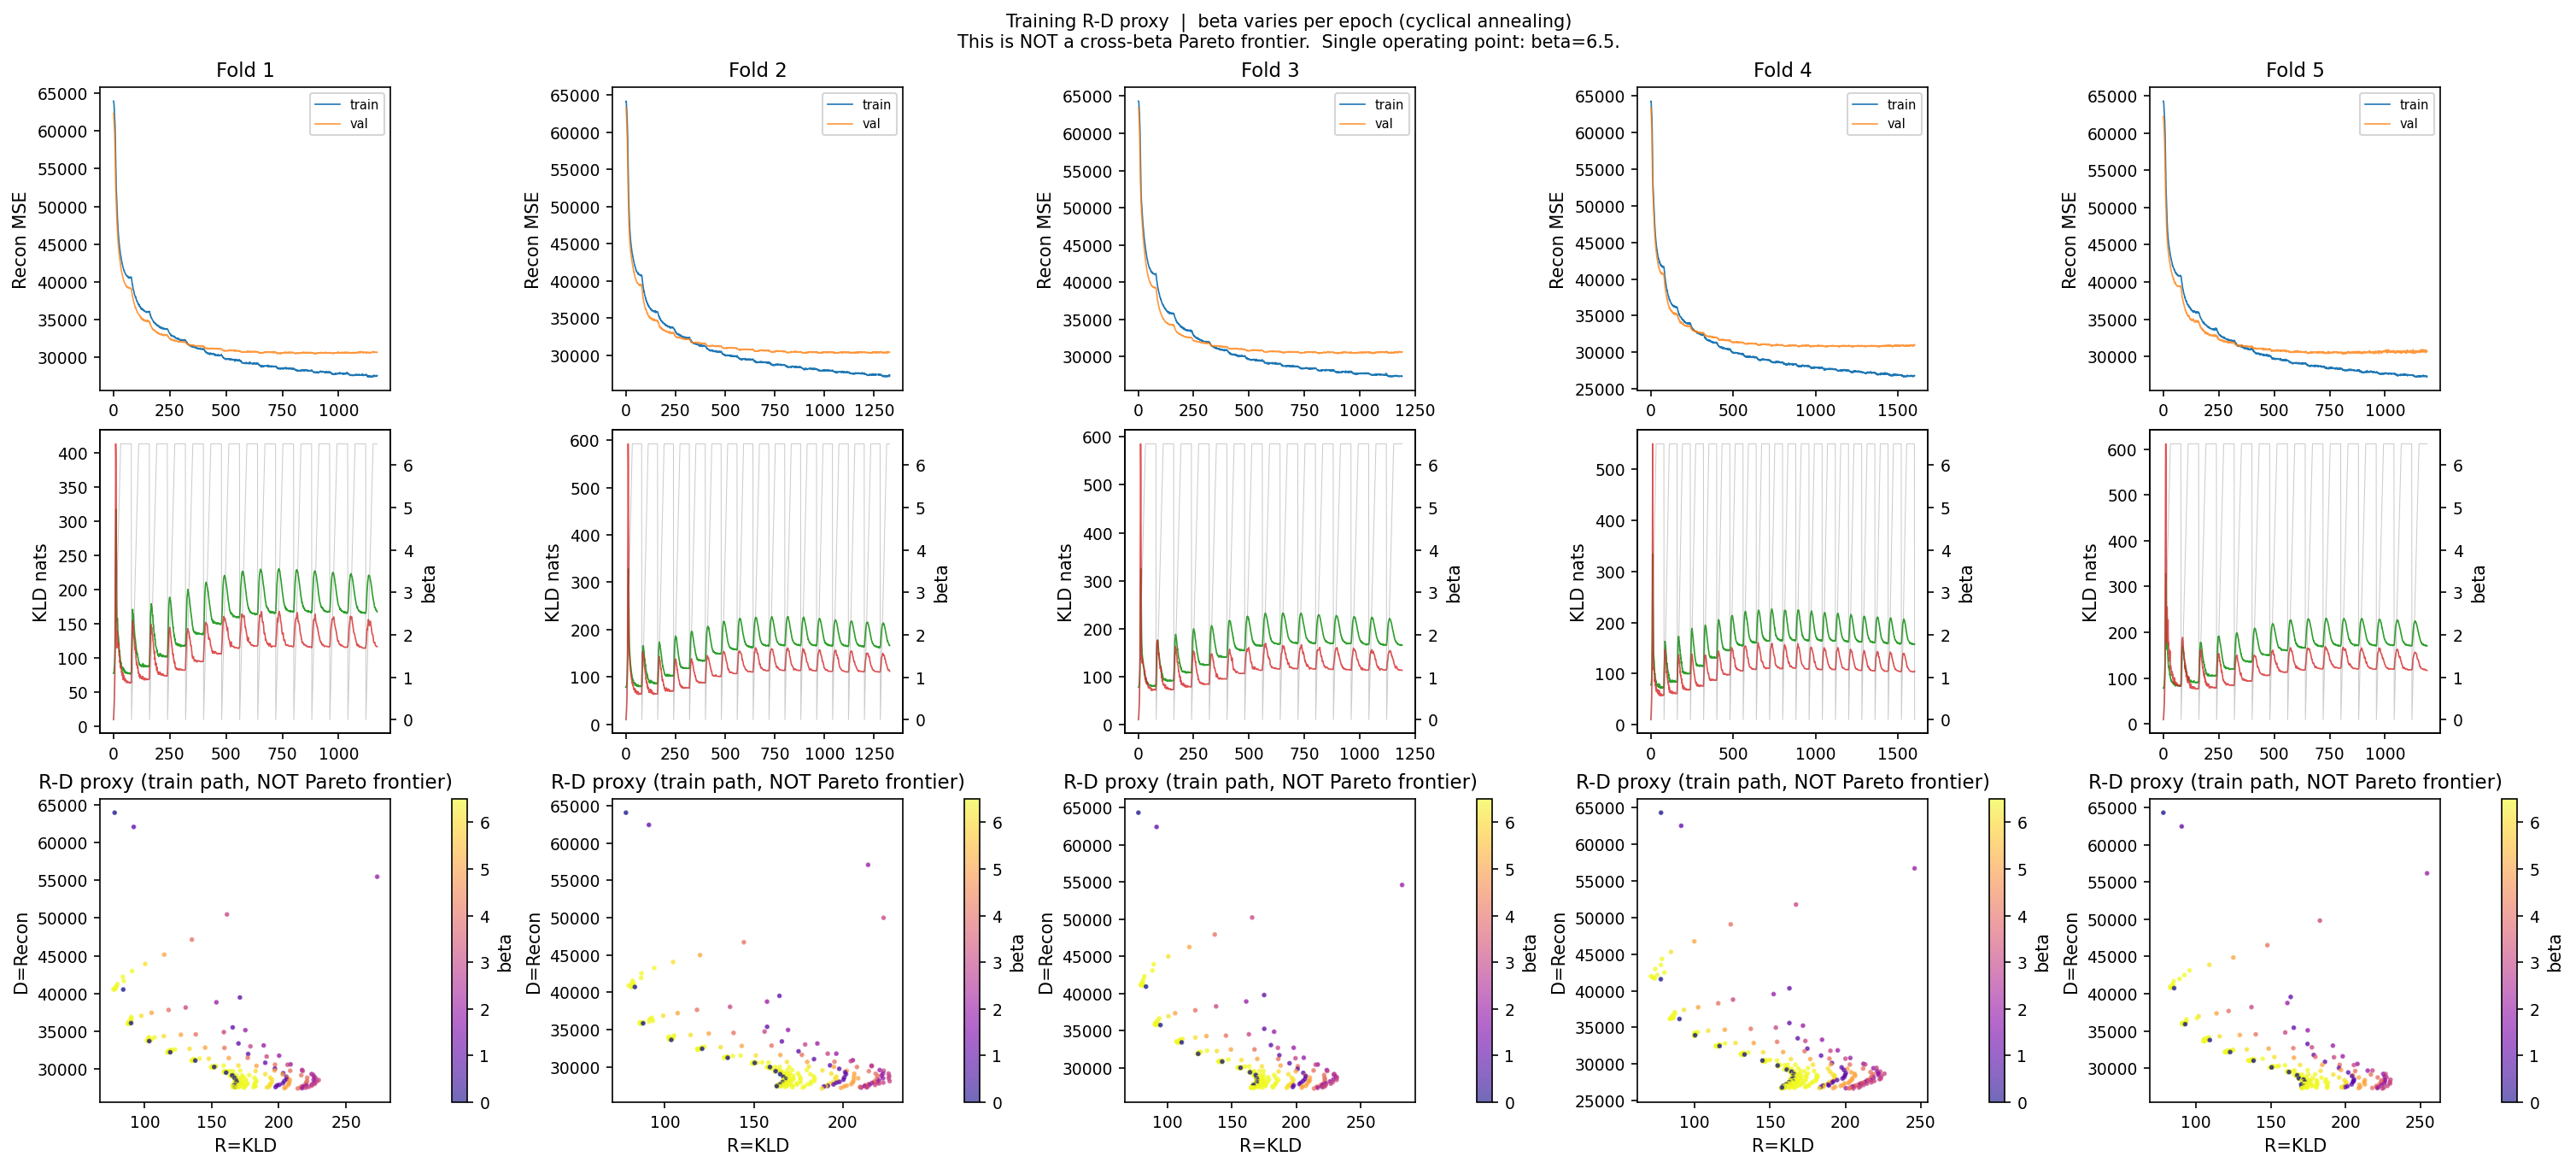

  [fig] 04_training_curves_rd_proxy.png  [pdf] 04_training_curves_rd_proxy.pdf


In [11]:
if histories is None:
    print("[SKIP] §4b: no histories")
else:
    n_h = len(histories)
    fig, axes = plt.subplots(3, n_h, figsize=(4*n_h, 9))
    if n_h == 1: axes = axes[:, None]
    for fi, h in enumerate(histories):
        ep  = np.arange(1, len(h["train_recon"])+1)
        beta_ = np.asarray(h["beta"], float)
        Dtr = np.asarray(h["train_recon"], float)
        Dvl = np.asarray(h["val_recon"],   float)
        Rtr = np.asarray(h["train_kld"],   float)
        Rvl = np.asarray(h["val_kld"],     float)
        axes[0,fi].plot(ep,Dtr,lw=0.8,label="train"); axes[0,fi].plot(ep,Dvl,lw=0.8,label="val",alpha=0.8)
        axes[0,fi].set_title(f"Fold {fi+1}"); axes[0,fi].set_ylabel("Recon MSE"); axes[0,fi].legend(fontsize=7)
        axes[1,fi].plot(ep,Rtr,lw=0.8,color="C2"); axes[1,fi].plot(ep,Rvl,lw=0.8,color="C3",alpha=0.8)
        ax1b=axes[1,fi].twinx(); ax1b.plot(ep,beta_,lw=0.5,color="grey",alpha=0.4)
        ax1b.set_ylabel("beta"); axes[1,fi].set_ylabel("KLD nats")
        sc = axes[2,fi].scatter(Rtr[::5],Dtr[::5],c=beta_[::5],cmap="plasma",s=3,alpha=0.6)
        plt.colorbar(sc,ax=axes[2,fi],label="beta"); axes[2,fi].set_xlabel("R=KLD"); axes[2,fi].set_ylabel("D=Recon")
        axes[2,fi].set_title("R-D proxy (train path, NOT Pareto frontier)")
    fig.suptitle(
        "Training R-D proxy  |  beta varies per epoch (cyclical annealing)\n"
        "This is NOT a cross-beta Pareto frontier.  Single operating point: beta=6.5.",
        fontsize=10
    )
    savefig("04_training_curves_rd_proxy.png", fig)

  [tbl] 04_ib_fold_summary.csv  (5 rows)
 fold  n_test  n_AD  n_CN  n_nan_y  n_active_units  frac_active_units  mean_kl_nats  tc_gaussian_lw_nats                                      tc_note
    1      37    19    18        0             256                1.0        0.4514              65.3215 exploratory - Gaussian approx + LW shrinkage
    2      37    19    18        0             256                1.0        0.4326              64.0422 exploratory - Gaussian approx + LW shrinkage
    3      37    19    18        0             256                1.0        0.4488              64.2934 exploratory - Gaussian approx + LW shrinkage
    4      36    18    18        0             256                1.0        0.4184              71.7004 exploratory - Gaussian approx + LW shrinkage
    5      36    19    17        0             256                1.0        0.4547              58.2897 exploratory - Gaussian approx + LW shrinkage


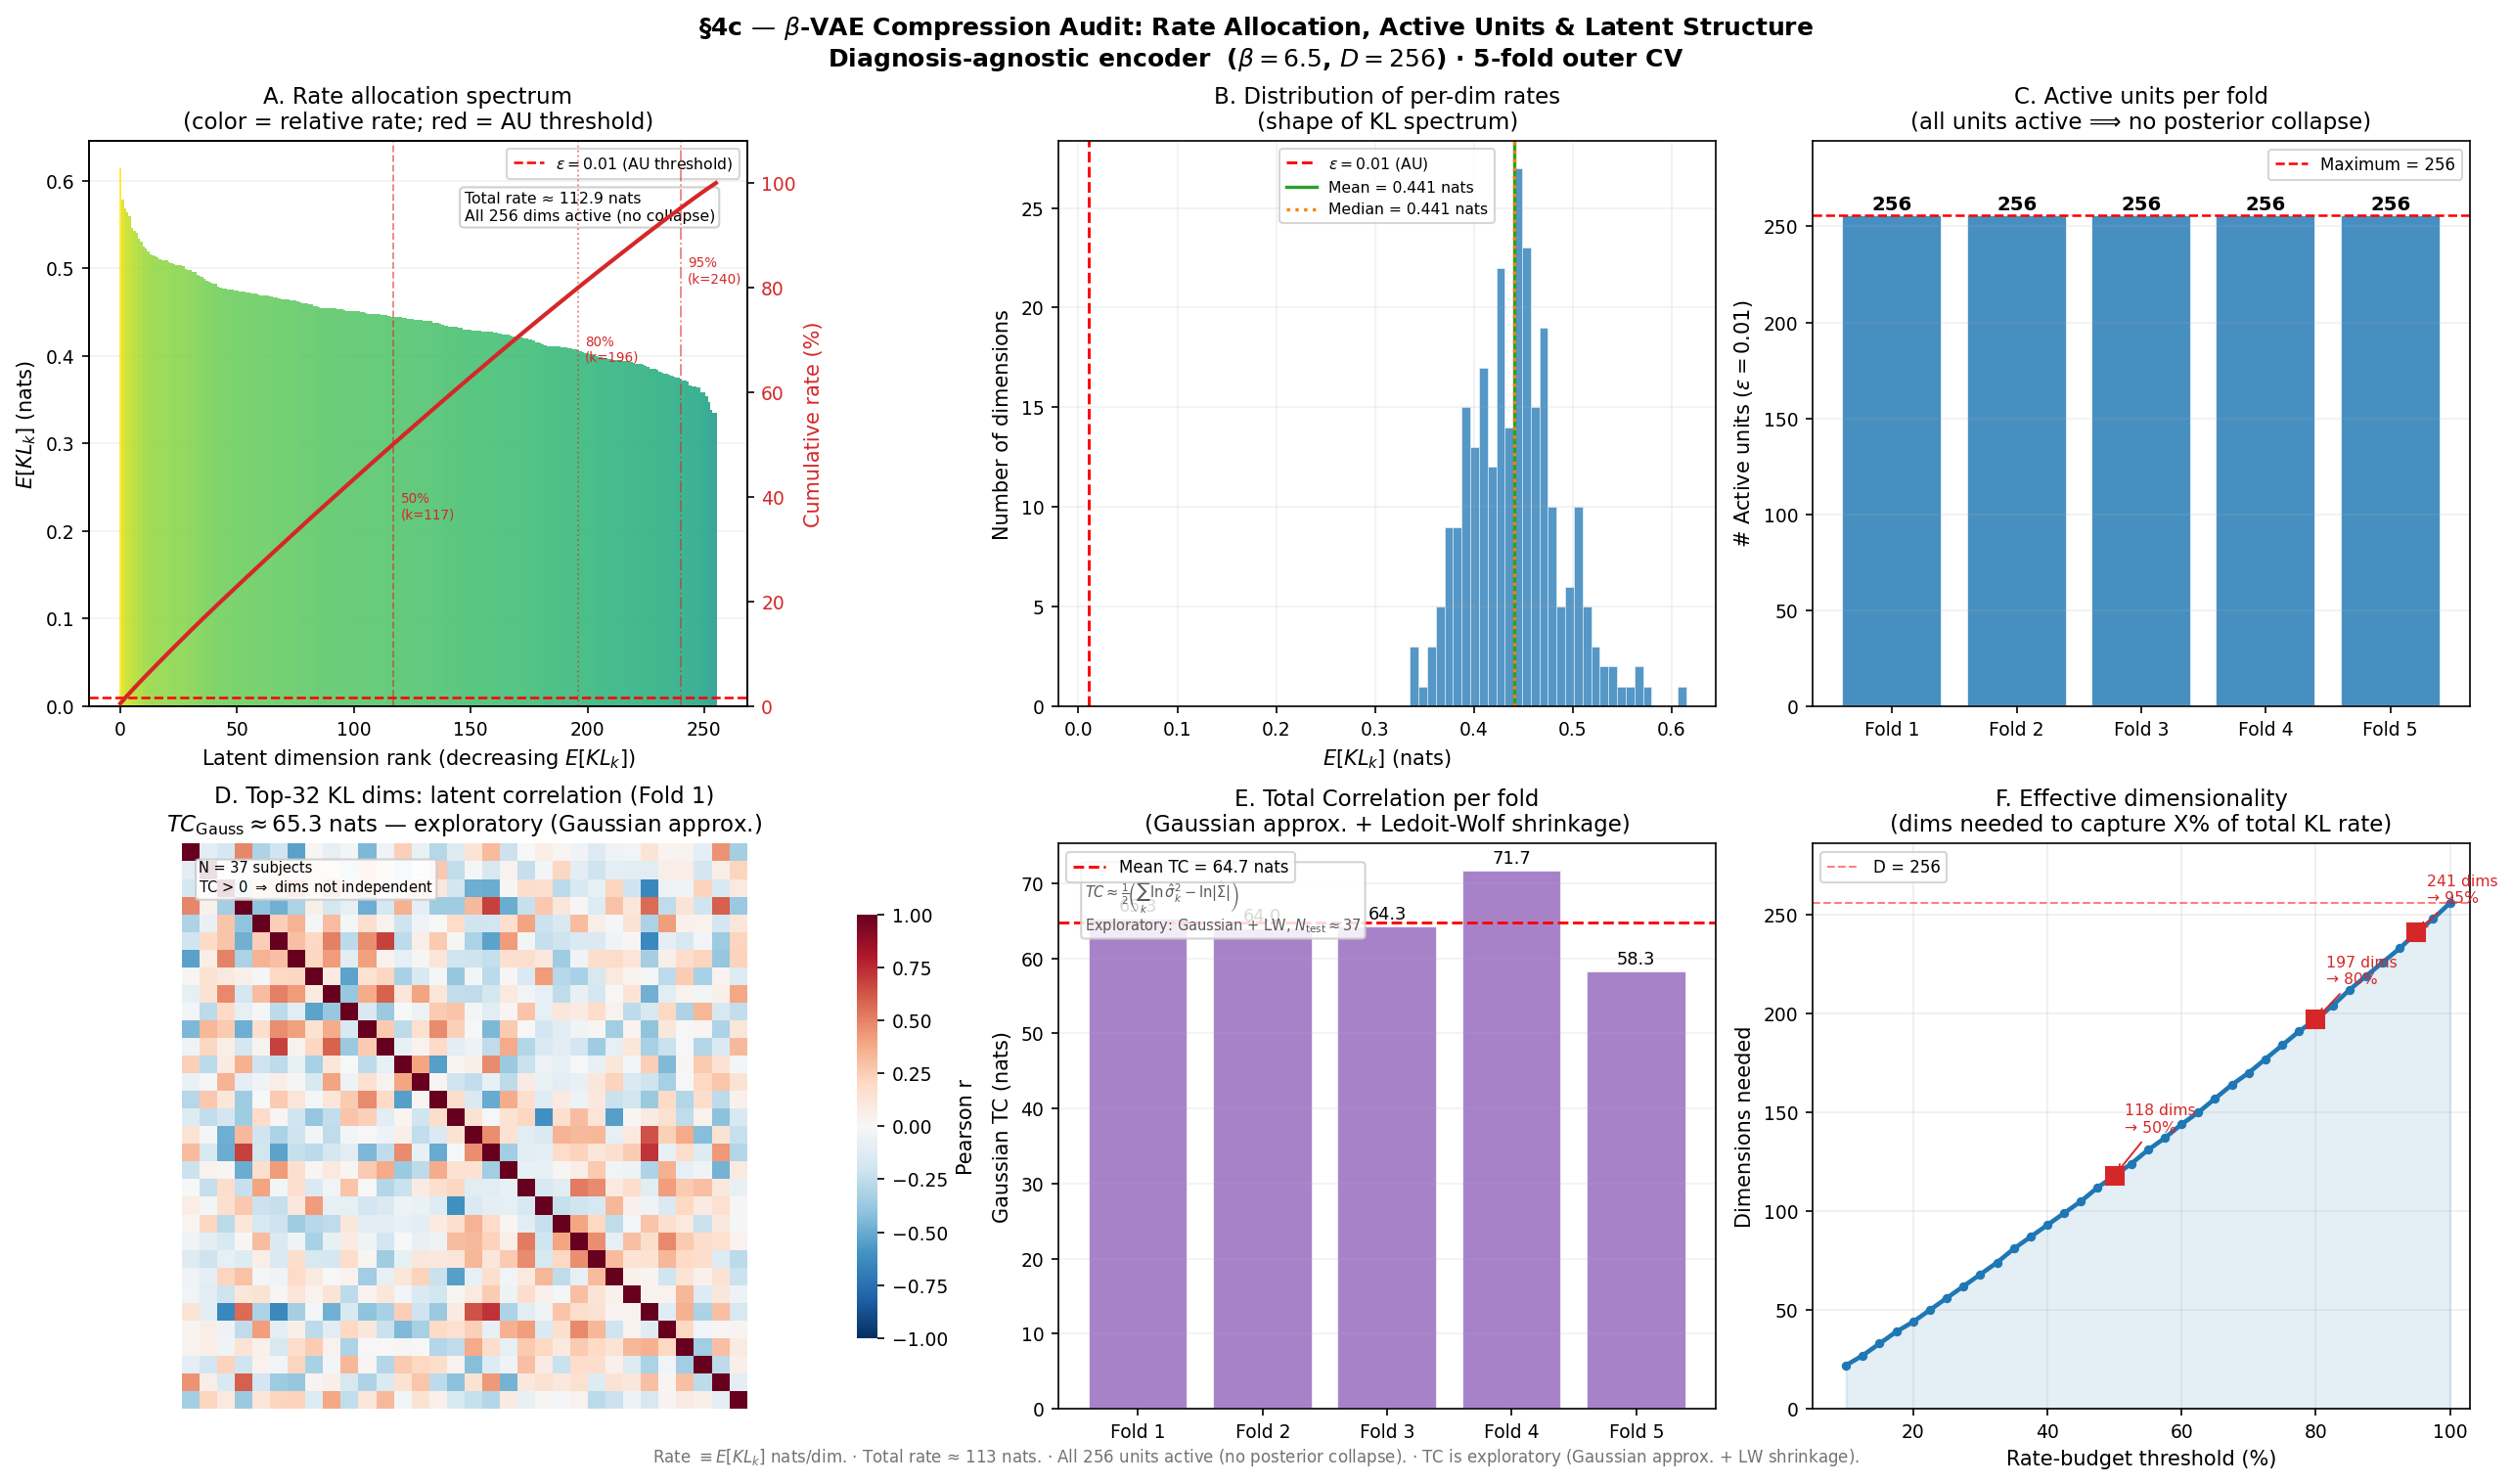

  [fig] 04_kl_active_units_latent_corr.png  [pdf] 04_kl_active_units_latent_corr.pdf
  [tbl] 04_kl_per_dimension.csv  (256 rows)


In [12]:
if not _REINFERENCE_AVAILABLE:
    print("[SKIP] §4c: no re-inference")
else:
    kl_folds, au_folds, tc_folds = {}, {}, {}
    for k in sorted(fold_mu_dict):
        mu  = fold_mu_dict[k]; lv = fold_logvar_dict.get(k)
        kl_folds[k] = per_dim_kl(mu, lv)
        au_folds[k] = active_units(mu)
        tc_folds[k] = tc_gaussian_lw(mu)

    kl_matrix = np.stack([kl_folds[k] for k in sorted(kl_folds)], 0)
    kl_mean, kl_std = kl_matrix.mean(0), kl_matrix.std(0)

    rows_ib = []
    for k in sorted(au_folds):
        y_k   = fold_y_dict.get(k, np.array([]))
        n_ad  = int((y_k==1).sum()); n_cn = int((y_k==0).sum()); n_nan = int(np.isnan(y_k).sum())
        rows_ib.append({
            "fold": k,
            "n_test": len(fold_mu_dict[k]),
            "n_AD": n_ad, "n_CN": n_cn, "n_nan_y": n_nan,
            "n_active_units": au_folds[k]["n_active"],
            "frac_active_units": round(au_folds[k]["frac_active"], 4),
            "mean_kl_nats": round(float(kl_folds[k].mean()), 4),
            "tc_gaussian_lw_nats": round(float(tc_folds[k]), 4),
            "tc_note": "exploratory - Gaussian approx + LW shrinkage",
        })
    df_ib = pd.DataFrame(rows_ib)
    save_table(df_ib, "04_ib_fold_summary.csv")
    print(df_ib.to_string(index=False))

    order        = np.argsort(-kl_mean)
    kl_sorted    = kl_mean[order]
    kl_cumsum    = np.cumsum(kl_sorted)
    kl_total     = float(kl_cumsum[-1])
    pct_cumsum   = kl_cumsum / kl_total * 100   # running % of total rate

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    axA, axB, axC, axD, axE, axF = axes.ravel()

    # ── Panel A: Rate allocation spectrum + cumulative rate ──────────────
    colors_a = plt.cm.viridis(kl_sorted / (kl_sorted.max() + 1e-12))
    axA.bar(np.arange(LATENT_DIM), kl_sorted, width=1.0,
            color=colors_a, alpha=0.88, linewidth=0, zorder=2)
    axA.axhline(0.01, color="red", lw=1.2, ls="--",
                label=r"$\varepsilon=0.01$ (AU threshold)", zorder=3)
    axA_r = axA.twinx()
    axA_r.plot(np.arange(LATENT_DIM), pct_cumsum,
               color="C3", lw=2.0, label="Cumulative rate (%)", zorder=4)
    for thresh, ls_t in [(50, "--"), (80, ":"), (95, "-.")]:
        idx_t = int(np.searchsorted(pct_cumsum, thresh))
        axA_r.axvline(idx_t, color="C3", lw=0.9, ls=ls_t, alpha=0.55)
        axA_r.text(idx_t + 3, thresh - 9,
                   f"{thresh}%\n(k={idx_t})", fontsize=6.5, color="C3", va="top")
    axA_r.set_ylabel("Cumulative rate (%)", color="C3")
    axA_r.tick_params(axis="y", labelcolor="C3")
    axA_r.set_ylim(0, 108)
    axA.set_xlabel(r"Latent dimension rank (decreasing $E[KL_k]$)")
    axA.set_ylabel(r"$E[KL_k]$ (nats)")
    axA.set_title("A. Rate allocation spectrum\n(color = relative rate; red = AU threshold)")
    axA.legend(loc="upper right", fontsize=7.5)
    axA.grid(alpha=0.18, axis="y", zorder=0)
    axA.text(0.57, 0.86,
             f"Total rate ≈ {kl_total:.1f} nats\n"
             f"All {LATENT_DIM} dims active (no collapse)",
             transform=axA.transAxes, fontsize=7.5,
             bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="0.8", alpha=0.92))

    # ── Panel B: KL distribution (shape of rate allocation) ──────────────
    axB.hist(kl_mean, bins=32, color="C0", alpha=0.76, edgecolor="white", lw=0.3)
    axB.axvline(0.01, color="red", lw=1.4, ls="--", label=r"$\varepsilon=0.01$ (AU)")
    axB.axvline(float(np.mean(kl_mean)), color="C2", lw=1.6,
                label=f"Mean = {float(np.mean(kl_mean)):.3f} nats")
    axB.axvline(float(np.median(kl_mean)), color="C1", lw=1.6, ls=":",
                label=f"Median = {float(np.median(kl_mean)):.3f} nats")
    axB.set_xlabel(r"$E[KL_k]$ (nats)")
    axB.set_ylabel("Number of dimensions")
    axB.set_title("B. Distribution of per-dim rates\n(shape of KL spectrum)")
    axB.legend(fontsize=7.5)
    axB.grid(alpha=0.18)

    # ── Panel C: Active units per fold ────────────────────────────────────
    fks = sorted(au_folds)
    n_active_vals = [au_folds[k]["n_active"] for k in fks]
    bars_c = axC.bar([f"Fold {k}" for k in fks], n_active_vals,
                     color="C0", alpha=0.82, edgecolor="white")
    axC.axhline(LATENT_DIM, color="red", lw=1.2, ls="--",
                label=f"Maximum = {LATENT_DIM}")
    for bar, val in zip(bars_c, n_active_vals):
        axC.text(bar.get_x() + bar.get_width() / 2, val + 0.5, str(val),
                 ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    axC.set_ylabel(r"# Active units ($\varepsilon=0.01$)")
    axC.set_ylim(0, LATENT_DIM * 1.15)
    axC.set_title("C. Active units per fold\n(all units active ⟹ no posterior collapse)")
    axC.legend(fontsize=8)
    axC.grid(alpha=0.18, axis="y")

    # ── Panel D: Correlation heatmap top-32 KL dims + TC annotation ───────
    k0 = sorted(fold_mu_dict)[0]
    top32 = np.argsort(-kl_mean)[:32]
    corr_matrix = np.corrcoef(fold_mu_dict[k0][:, top32].T)
    sns.heatmap(corr_matrix, ax=axD, cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=False, yticklabels=False,
                cbar_kws={"label": "Pearson r", "shrink": 0.75})
    tc_val = tc_folds.get(k0, np.nan)
    axD.set_title(
        f"D. Top-32 KL dims: latent correlation (Fold {k0})\n"
        rf"$TC_{{\mathrm{{Gauss}}}}\approx{tc_val:.1f}$ nats — exploratory (Gaussian approx.)"
    )
    axD.text(0.03, 0.97,
             f"N = {len(fold_mu_dict[k0])} subjects\n"
             r"TC > 0 $\Rightarrow$ dims not independent",
             transform=axD.transAxes, va="top", fontsize=7,
             bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="0.8", alpha=0.88))

    # ── Panel E: Total Correlation (TC) across folds ──────────────────────
    tc_ks  = sorted(tc_folds)
    tc_vals = [float(tc_folds[k]) for k in tc_ks]
    axE.bar([f"Fold {k}" for k in tc_ks], tc_vals,
            color="C4", alpha=0.82, edgecolor="white")
    tc_mean_val = float(np.nanmean(tc_vals))
    axE.axhline(tc_mean_val, color="red", lw=1.4, ls="--",
                label=f"Mean TC = {tc_mean_val:.1f} nats")
    for i, (k, v) in enumerate(zip(tc_ks, tc_vals)):
        axE.text(i, v + 0.4, f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
    axE.set_ylabel("Gaussian TC (nats)")
    axE.set_title("E. Total Correlation per fold\n(Gaussian approx. + Ledoit-Wolf shrinkage)")
    axE.legend(fontsize=8)
    axE.grid(alpha=0.18, axis="y")
    axE.text(0.04, 0.94,
             r"$TC \approx \frac{1}{2}\!\left(\sum_k\ln\hat\sigma_k^2 - \ln|\hat\Sigma|\right)$"
             "\nExploratory: Gaussian + LW, $N_{\\rm test}\\approx 37$",
             transform=axE.transAxes, va="top", fontsize=7, color="0.35",
             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.85))

    # ── Panel F: Effective dimensionality curve ───────────────────────────
    thresh_grid   = np.arange(10, 100.5, 2.5)
    n_dims_needed = [min(int(np.searchsorted(pct_cumsum, t)) + 1, LATENT_DIM)
                     for t in thresh_grid]
    axF.plot(thresh_grid, n_dims_needed, "o-", color="C0", lw=2.2, ms=3.5)
    axF.fill_between(thresh_grid, 0, n_dims_needed, alpha=0.12, color="C0")
    for t_ann, dy in [(50, 22), (80, 18), (95, 15)]:
        n_ann = min(int(np.searchsorted(pct_cumsum, t_ann)) + 1, LATENT_DIM)
        axF.plot(t_ann, n_ann, "s", ms=9, color="C3", zorder=5)
        axF.annotate(f"{n_ann} dims\n→ {t_ann}%",
                     xy=(t_ann, n_ann), xytext=(t_ann + 1.5, n_ann + dy),
                     fontsize=7.5, color="C3",
                     arrowprops=dict(arrowstyle="->", color="C3", lw=0.9))
    axF.axhline(LATENT_DIM, color="red", lw=1, ls="--", alpha=0.5,
                label=f"D = {LATENT_DIM}")
    axF.set_xlabel("Rate-budget threshold (%)")
    axF.set_ylabel("Dimensions needed")
    axF.set_title("F. Effective dimensionality\n(dims needed to capture X% of total KL rate)")
    axF.grid(alpha=0.22)
    axF.legend(fontsize=8)
    axF.set_ylim(0, LATENT_DIM + 30)
    axF.set_xlim(5, 103)

    fig.suptitle(
        r"§4c — $\beta$-VAE Compression Audit: Rate Allocation, Active Units & Latent Structure"
        "\n"
        r"Diagnosis-agnostic encoder  ($\beta = 6.5$, $D = 256$) · 5-fold outer CV",
        fontsize=12, fontweight="bold"
    )
    fig.text(
        0.5, 0.005,
        r"Rate $\equiv E[KL_k]$ nats/dim. · "
        f"Total rate ≈ {kl_total:.0f} nats. · "
        "All 256 units active (no posterior collapse). · "
        "TC is exploratory (Gaussian approx. + LW shrinkage).",
        ha="center", va="bottom", fontsize=8, color="0.45"
    )
    savefig("04_kl_active_units_latent_corr.png", fig)
    #savefig("04_kl_active_units_latent_corr.png", fig)
    save_table(
        pd.DataFrame({"dim":np.arange(LATENT_DIM),"kl_mean":kl_mean,"kl_std":kl_std,
                      **{f"kl_fold{k}":kl_folds[k] for k in sorted(kl_folds)}}),
        "04_kl_per_dimension.csv"
    )

### Por qué la figura nueva es conceptualmente más rica para el curso

| Panel | Concepto IT que ilustra |
|---|---|
| A | Espectro de tasa: cómo el β-VAE distribuye su "presupuesto" de bits/nats entre 256 dimensiones |
| B | Forma de la distribución de tasas: ¿exponencial, uniforme, concentrada? |
| C | Unidades activas: dimensionalidad efectiva, colapso posterior |
| D | Correlación latente + TC: alejamiento de la factorización $q(z) = \prod_k q(z_k)$ |
| E | TC por fold: medida multivaridada de dependencia entre dimensiones latentes |
| F | Dimensionalidad efectiva: ¿cuántas dimensiones concentran el 80%, 95% de la tasa? |

---

## 2. Estudio profundo de la figura §7

La figura se llama **"Exact raw-score MaxEnt geometry, calibration-induced score warping, and entropy redistribution"** y tiene cuatro paneles. Es probablemente la figura más elegante del notebook porque conecta álgebra pura con geometría empírica.

### Contexto: el pipeline de scores

El clasificador produce una cadena de transformaciones deterministas:
```
u = (z₁,...,z₂₅₆, Age, Sex)
        ↓
m_raw = w⊤u + b          ← margen lineal bruto
        ↓
p_raw = σ(m_raw)          ← probabilidad cruda
        ↓
p_cal  (calibración)      ← probabilidad calibrada
        ↓
s_cal = logit(p_cal)      ← logit calibrado
```

---

### Panel A: Exact raw-score MaxEnt geometry

**¿Qué muestra?** Para cada sujeto, un punto `(m_raw, H_raw)`. La curva negra es `h₂(σ(m))`.

**La identidad exacta:**
```
H_raw = -p_raw·log₂(p_raw) - (1-p_raw)·log₂(1-p_raw) = h₂(σ(m_raw))
```

Esto *no es una aproximación*. Es una cadena de igualdades algebraicas:
```
H_raw = h₂(p_raw)     [def. entropía binaria]
      = h₂(σ(m_raw))  [porque p_raw = σ(m_raw) por def. de regresión logística]
```

**Por eso todos los puntos caen exactamente sobre la curva** — el error medio es `0.0` (verificado numéricamente). Si algún punto se desviara, habría un bug.

**La conexión con MaxEnt:** La regresión logística es la solución al problema MaxEnt restringido:
```
max H(Y|u)  s.t.  E[f(u)] = c   (restricciones lineales sobre features)

## §5 — Latent MI and Confounding  [Training Set Only]

> **Methodological note — v2/v3 correction:** MI rankings are computed **exclusively
> on training-set latents** (`fold_mu_train_dict`). Using test-set latents to rank
> dimensions and then evaluate the same test set creates information leakage.
>
> **v3 additional note:** Training-set latents now correctly encode training-set subjects
> (via `train_dev_tensor_idx.npy`). v2 encoded local-pool-indexed subjects.
>
> Because the encoder was trained diagnosis-agnostically, the quantities in this section
> describe **downstream recoverability** of AD/CN information from latent `μ(x)`, not
> direct supervised feature learning inside the encoder.
>
> **Scope complement:** §§5a-5c stay latent-only. §5d then asks the Reviewer #2 question
> directly at the readout level: how much CN/AD discrimination is captured by latent
> connectome structure versus `Age + Sex` alone?

### Heuristic Marginal Diagnostic Ratio [not a canonical IT quantity]

$$
r_k = \frac{I(z_k; Y)}{I(z_k; Y) + I(z_k; \mathrm{Site}) + I(z_k; \mathrm{Age}) + I(z_k; \mathrm{Sex}) + \varepsilon}
$$

**Caveats** (mandatory disclosure):
- This is a **marginal** ratio — it does not prove conditional deconfounding
- It **underestimates** distributed multivariate confounding (dimensions can jointly encode
  confounders even when each individually appears diagnostic)
- It is not a canonical information-theoretic quantity and should not be cited as such


In [13]:
_MI_AVAILABLE = False
if not _REINFERENCE_AVAILABLE or meta_df is None:
    print("[SKIP] §5: requires re-inference and metadata")
else:
    _MI_AVAILABLE = True
    _site_col = next((c for c in ["Manufacturer","Site","site","Scanner","Site3"]
                      if c in meta_df.columns), None)
    meta_idx_full = meta_df.set_index("tensor_idx") if "tensor_idx" in meta_df.columns else meta_df

    def _get_meta_vals(tidx_arr, col):
        return np.array([
            meta_idx_full.loc[i, col] if i in meta_idx_full.index else np.nan
            for i in tidx_arr
        ])

    mi_per_fold_train = {}

    for k in sorted(fold_mu_train_dict):
        Z_tr   = fold_mu_train_dict[k]
        y_tr   = fold_y_train_dict.get(k, np.full(len(Z_tr), np.nan))
        train_tidx = np.load(fold_train_tidx_paths[k]).astype(int)

        fm = {}
        fm["Y_AD_CN"] = mi_classif(Z_tr, y_tr)

        if _site_col and _site_col in meta_idx_full.columns:
            from sklearn.preprocessing import LabelEncoder
            sv = pd.Series(_get_meta_vals(train_tidx, _site_col)).fillna("Unknown").values
            le = LabelEncoder(); se = le.fit_transform(sv)
            fm["Site"] = mi_classif(Z_tr, se) if len(np.unique(se))>=2 else np.full(LATENT_DIM,np.nan)
        else:
            fm["Site"] = np.full(LATENT_DIM, np.nan)

        for col, fn in [("Age", mi_regress), ("Sex", mi_classif)]:
            if col in meta_idx_full.columns:
                vals = _get_meta_vals(train_tidx, col)
                if col == "Sex":
                    from sklearn.preprocessing import LabelEncoder
                    sv2 = pd.Series(vals).fillna("Unknown").astype(str).values
                    le2 = LabelEncoder(); se2 = le2.fit_transform(sv2)
                    fm[col] = mi_classif(Z_tr, se2) if len(np.unique(se2))>=2 else np.full(LATENT_DIM,np.nan)
                else:
                    fm[col] = fn(Z_tr, vals)
            else:
                fm[col] = np.full(LATENT_DIM, np.nan)

        mi_per_fold_train[k] = fm

    variables = list(next(iter(mi_per_fold_train.values())).keys())
    mi_agg     = {v: np.nanmean(np.stack([mi_per_fold_train[k][v] for k in sorted(mi_per_fold_train)],0),0) for v in variables}
    mi_agg_std = {v: np.nanstd( np.stack([mi_per_fold_train[k][v] for k in sorted(mi_per_fold_train)],0),0) for v in variables}

    print("[OK] §5 train-only MI computed")
    for v, arr in mi_agg.items():
        print(f"  {v:12s}: mean={np.nanmean(arr):.4f}  max={np.nanmax(arr):.4f}")

    rows_mi = []
    for k in sorted(mi_per_fold_train):
        for v in variables:
            rows_mi.append({"fold":k,"variable":v,
                            "mi_sum_nats": float(np.nansum(mi_per_fold_train[k][v])),
                            "mi_mean_nats":float(np.nanmean(mi_per_fold_train[k][v])),
                            "mi_max_nats": float(np.nanmax(mi_per_fold_train[k][v])),
                            "data_split":"train_only"})
    save_table(pd.DataFrame(rows_mi), "05_latent_mi_summary_by_fold.csv")

[OK] §5 train-only MI computed
  Y_AD_CN     : mean=0.0203  max=0.0524
  Site        : mean=0.0236  max=0.0690
  Age         : mean=0.0230  max=0.0752
  Sex         : mean=0.0176  max=0.0559
  [tbl] 05_latent_mi_summary_by_fold.csv  (20 rows)


In [14]:
if not _MI_AVAILABLE:
    print("[SKIP] §5b")
else:
    eps_p = 1e-9
    mi_Y    = mi_agg["Y_AD_CN"]
    mi_site = np.nan_to_num(mi_agg.get("Site", np.zeros(LATENT_DIM)), nan=0.0)
    mi_age  = np.nan_to_num(mi_agg.get("Age",  np.zeros(LATENT_DIM)), nan=0.0)
    mi_sex  = np.nan_to_num(mi_agg.get("Sex",  np.zeros(LATENT_DIM)), nan=0.0)
    mi_Y_nn = np.nan_to_num(mi_Y, nan=0.0)

    # Heuristic marginal diagnostic ratio
    # CAVEAT: marginal, not conditional; not a canonical IT quantity
    heuristic_mdr = mi_Y_nn / (mi_Y_nn + mi_site + mi_age + mi_sex + eps_p)

    # ------------------------------------------------------------------
    # Weight extraction audit for the saved raw logreg pipelines
    # ------------------------------------------------------------------
    _WEIGHTS_AVAILABLE = False
    logreg_w_folds = {}
    weight_audit_rows = []

    def _extract_logreg_coef_from_artifact(artifact):
        """
        Robustly recover the coefficient vector of the final logistic model
        from a saved sklearn/imblearn Pipeline-like artifact.
        """
        est = artifact

        # Typical case: sklearn / imblearn Pipeline
        if hasattr(est, "named_steps"):
            if "model" in est.named_steps:
                est = est.named_steps["model"]
            elif len(est.named_steps):
                est = list(est.named_steps.values())[-1]

        # Defensive unwrapping for wrapped estimators
        for attr in ["estimator", "base_estimator"]:
            if hasattr(est, attr):
                est = getattr(est, attr)

        if not hasattr(est, "coef_"):
            raise AttributeError(
                f"Final estimator of type {type(est).__name__} has no coef_ attribute"
            )

        coef = np.asarray(est.coef_, dtype=float)
        if coef.ndim == 2:
            if coef.shape[0] != 1:
                raise ValueError(f"Expected binary classifier coef_ with shape (1, D), got {coef.shape}")
            coef = coef[0]

        if coef.shape[0] < LATENT_DIM:
            raise ValueError(
                f"Coefficient vector shorter than LATENT_DIM: got {coef.shape[0]}, expected >= {LATENT_DIM}"
            )

        return coef[:LATENT_DIM]

    for k, p in sorted(fold_logreg_paths.items()):
        row = {
            "fold": int(k),
            "artifact_path": str(p) if p else None,
            "artifact_exists": bool(p and p.exists()),
            "loaded_ok": False,
            "coef_extracted": False,
            "n_coef": np.nan,
            "status": "missing_artifact",
            "message": "",
        }

        if not (p and p.exists()):
            weight_audit_rows.append(row)
            continue

        try:
            clf = joblib.load(p)
            row["loaded_ok"] = True
            w = _extract_logreg_coef_from_artifact(clf)
            logreg_w_folds[k] = w
            row["coef_extracted"] = True
            row["n_coef"] = int(len(w))
            row["status"] = "ok"
            row["message"] = "coef_ extracted successfully"
        except Exception as e:
            row["status"] = "failed"
            row["message"] = str(e)
            print(f"  [WARN] fold {k} weight extraction failed: {e}")

        weight_audit_rows.append(row)

    df_weight_audit = pd.DataFrame(weight_audit_rows)
    save_table(df_weight_audit, "05b_logreg_weight_extraction_audit.csv")

    if logreg_w_folds:
        _WEIGHTS_AVAILABLE = True
        w_stack = np.stack([logreg_w_folds[k] for k in sorted(logreg_w_folds)], axis=0)
        w_mean = w_stack.mean(axis=0)
        w_std  = w_stack.std(axis=0)
        w_abs  = np.abs(w_mean)
        w_rank_order = np.argsort(-w_abs)

        print(
            f"[OK] §5b: logreg weights extracted for {len(logreg_w_folds)}/{len(fold_logreg_paths)} folds. "
            "by_w_abs ranking is defined."
        )
    else:
        _WEIGHTS_AVAILABLE = False
        w_mean = np.full(LATENT_DIM, np.nan)
        w_std  = np.full(LATENT_DIM, np.nan)
        w_abs  = np.full(LATENT_DIM, np.nan)
        w_rank_order = None

        print("[WARN] §5b: no logreg weights extracted — by_w_abs ranking is undefined.")
        print("       §5c |w_k| scatter and §6 by_w_abs results must not be interpreted until §6 is updated.")

    df_latent = pd.DataFrame({
        "dim": np.arange(LATENT_DIM),
        "mi_Y_train_nats": mi_Y,
        "mi_Y_std": mi_agg_std["Y_AD_CN"],
        "mi_site_nats": mi_agg.get("Site", np.full(LATENT_DIM, np.nan)),
        "mi_age_nats":  mi_agg.get("Age",  np.full(LATENT_DIM, np.nan)),
        "mi_sex_nats":  mi_agg.get("Sex",  np.full(LATENT_DIM, np.nan)),
        "heuristic_marginal_diagnostic_ratio": heuristic_mdr,
        "w_mean": w_mean,
        "w_std": w_std,
        "w_abs": w_abs,
        "weights_available": bool(_WEIGHTS_AVAILABLE),
        "kl_mean": kl_mean if "kl_mean" in dir() else np.nan,
    })
    save_table(df_latent, "05_latent_mi_train_only.csv")

    print("[OK] §5b latent stats saved")
    print(f"Top-5 dims by I(z;Y): {np.argsort(-mi_Y_nn)[:5].tolist()}")
    print(f"Top-5 heuristic MDR: {np.argsort(-heuristic_mdr)[:5].tolist()}")
    if _WEIGHTS_AVAILABLE:
        print(f"Top-5 dims by |w|: {w_rank_order[:5].tolist()}")

  [tbl] 05b_logreg_weight_extraction_audit.csv  (5 rows)
[OK] §5b: logreg weights extracted for 5/5 folds. by_w_abs ranking is defined.
  [tbl] 05_latent_mi_train_only.csv  (256 rows)
[OK] §5b latent stats saved
Top-5 dims by I(z;Y): [4, 102, 26, 33, 119]
Top-5 heuristic MDR: [12, 33, 236, 34, 102]
Top-5 dims by |w|: [0, 212, 70, 60, 161]


  [tbl] 05c_top_latent_dimensions_overview.csv  (32 rows)
  [tex] 05c_top_latent_dimensions_overview.tex


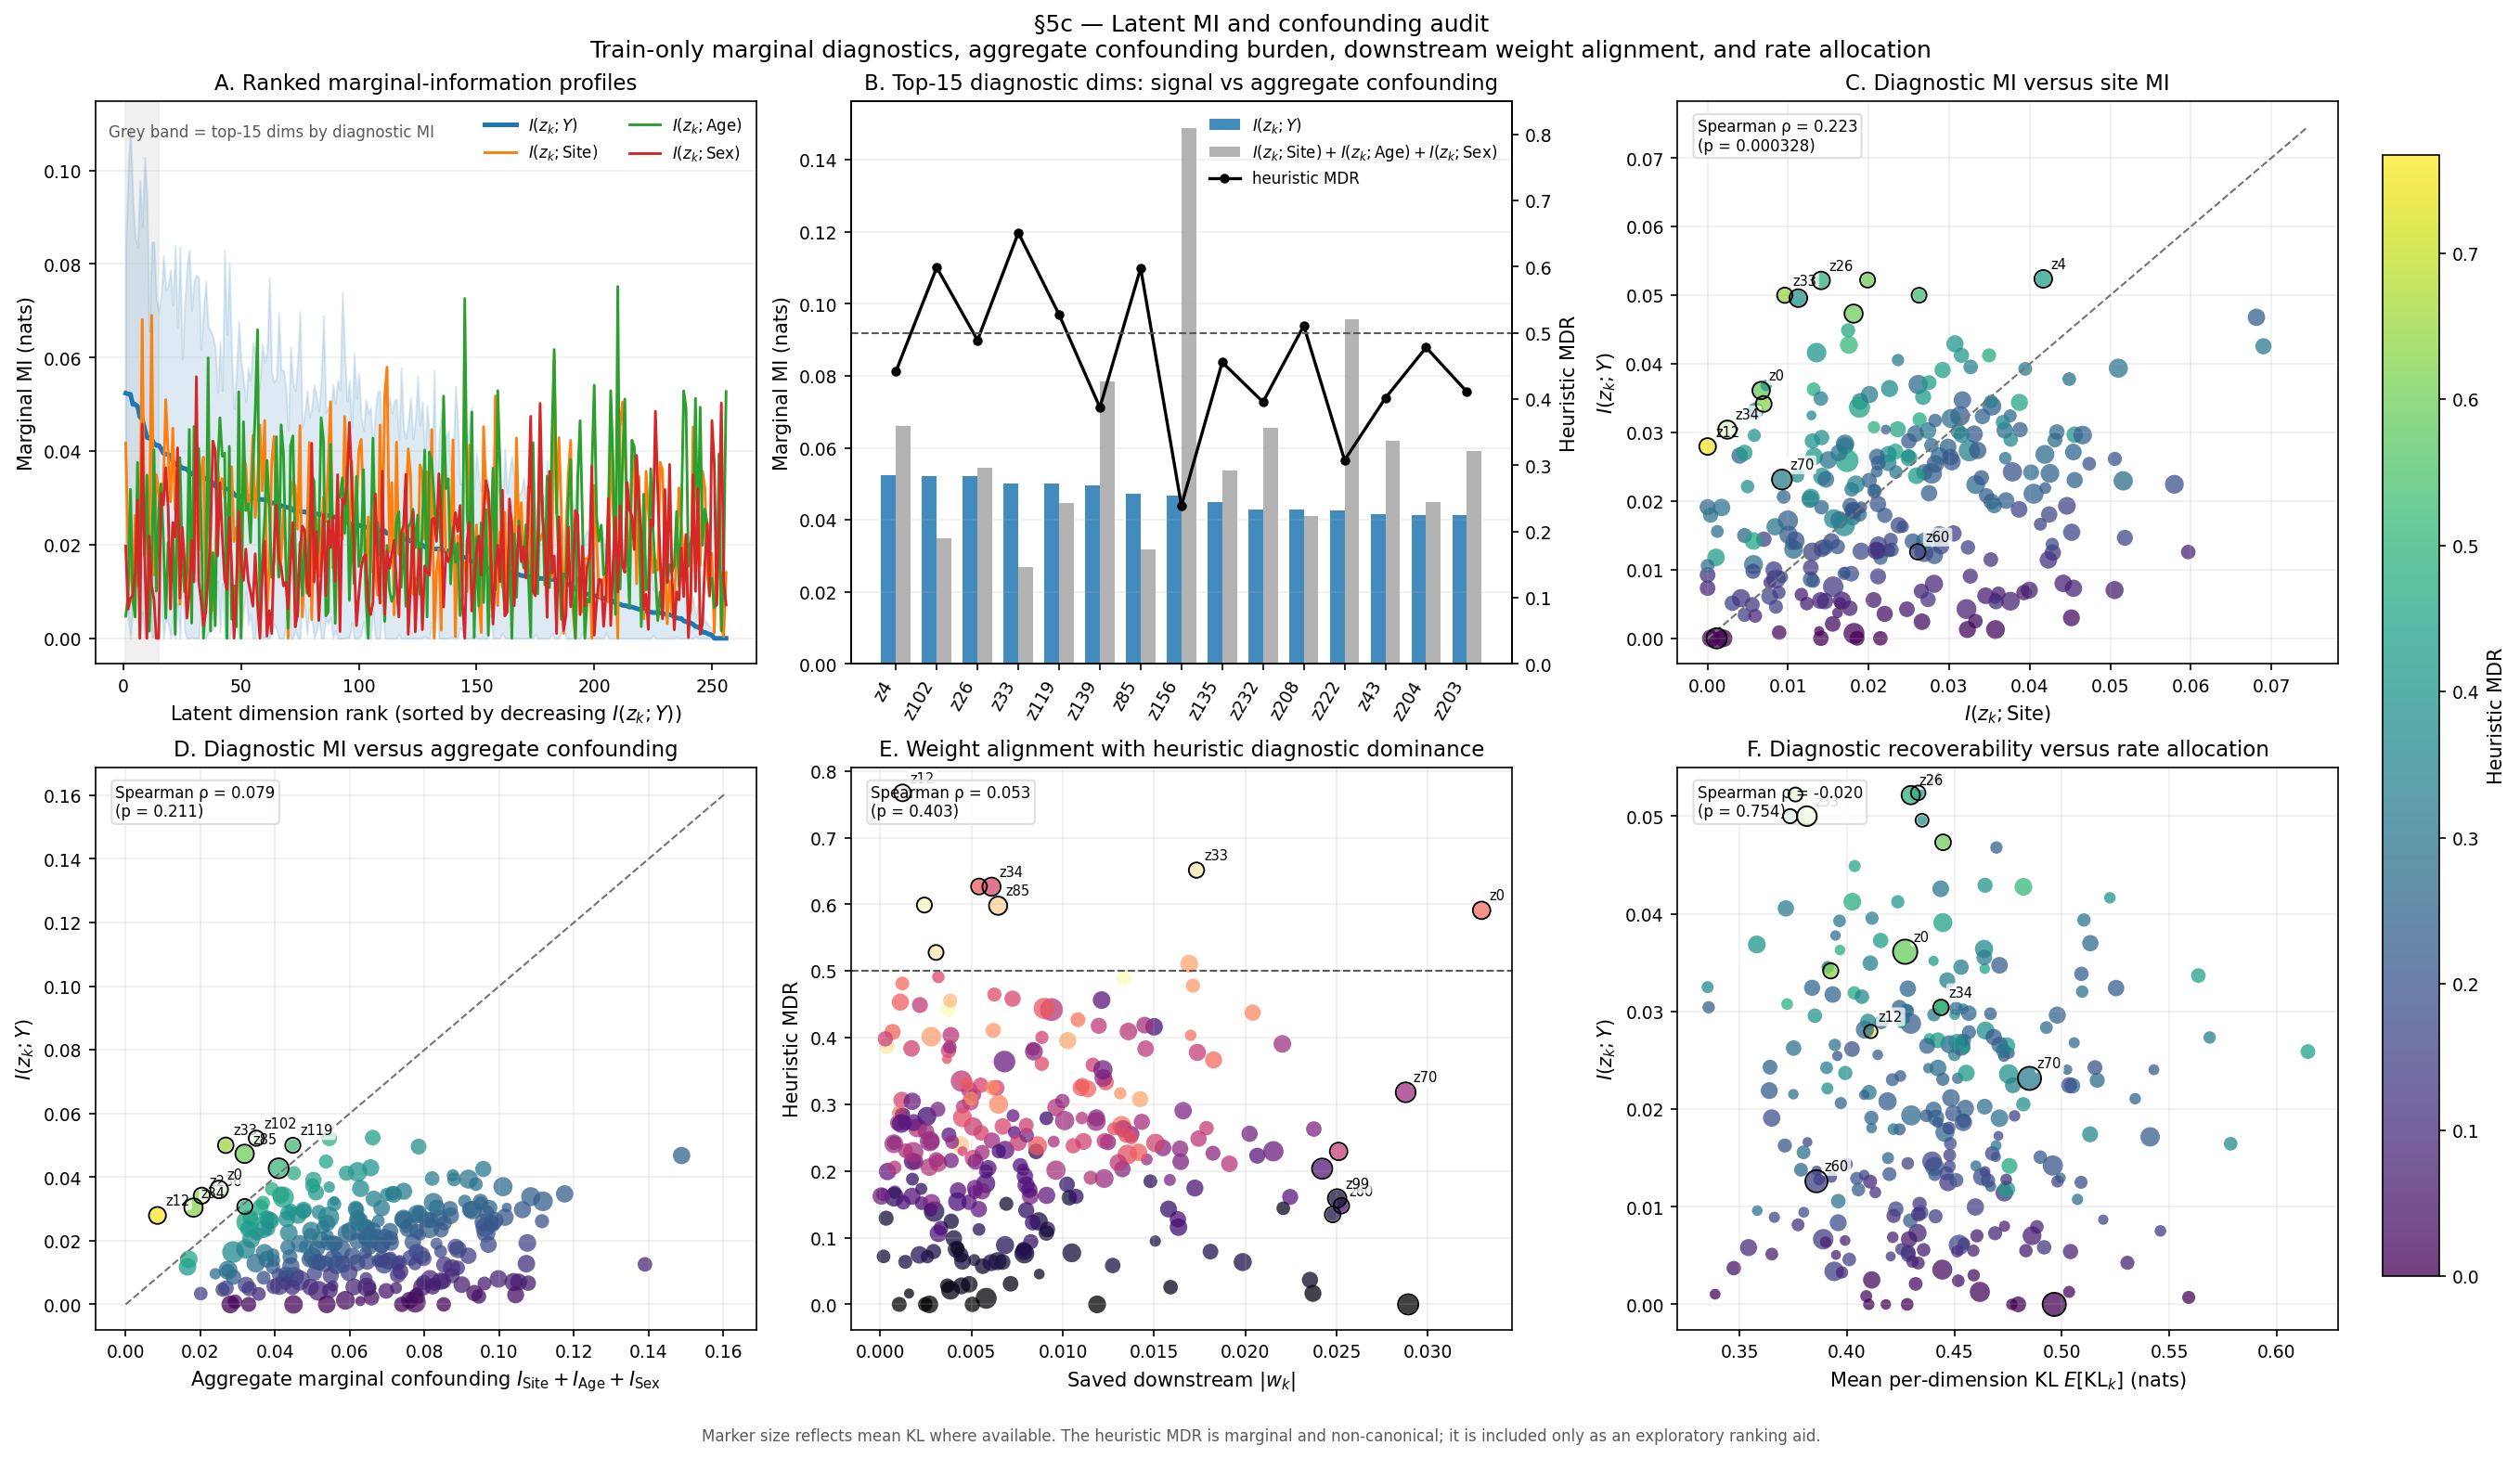

  [fig] 05_latent_mi_confounding.png  [pdf] 05_latent_mi_confounding.pdf
[OK] §5c plots saved


In [15]:
if not _MI_AVAILABLE:
    print("[SKIP] §5c")
else:
    from scipy.stats import spearmanr

    # ------------------------------------------------------------------
    # Helper data structures for a richer §5c visual audit
    # ------------------------------------------------------------------
    order_Y = np.argsort(-mi_Y_nn)
    order_mdr = np.argsort(-heuristic_mdr)
    total_confound = mi_site + mi_age + mi_sex

    def _rank_from_order(order):
        r = np.empty(len(order), dtype=int)
        r[np.asarray(order, dtype=int)] = np.arange(1, len(order) + 1)
        return r

    def _safe_marker_sizes(arr, smin=26, smax=140):
        arr = np.asarray(arr, float)
        finite = np.isfinite(arr)
        out = np.full(arr.shape, 0.5 * (smin + smax), dtype=float)
        if finite.any():
            amin = np.nanmin(arr[finite])
            amax = np.nanmax(arr[finite])
            if np.isclose(amax, amin):
                out[finite] = 0.5 * (smin + smax)
            else:
                out[finite] = smin + (arr[finite] - amin) * (smax - smin) / (amax - amin)
        return out

    def _annotate_latent_dims(ax, x, y, dims, prefix="z", max_labels=8, fontsize=7):
        for d in dims[:max_labels]:
            ax.annotate(
                f"{prefix}{int(d)}",
                (float(x[d]), float(y[d])),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=fontsize,
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75),
            )

    rank_y = _rank_from_order(order_Y)
    rank_mdr = _rank_from_order(order_mdr)

    if ("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE:
        order_w = np.argsort(-np.nan_to_num(w_abs, nan=-np.inf))
        rank_w = _rank_from_order(order_w)
    else:
        order_w = None
        rank_w = np.full(LATENT_DIM, np.nan)

    # Top dimensions to summarize in the companion table
    top_union = np.unique(
        np.concatenate([
            order_Y[:15],
            order_mdr[:15],
            order_w[:10] if order_w is not None else np.array([], dtype=int),
        ])
    )

    df_5c_top = pd.DataFrame({
        "dim": top_union.astype(int),
        "rank_by_mi_Y": rank_y[top_union],
        "rank_by_heuristic_mdr": rank_mdr[top_union],
        "rank_by_abs_w": rank_w[top_union],
        "mi_Y_train_nats": mi_Y_nn[top_union],
        "mi_site_nats": mi_site[top_union],
        "mi_age_nats": mi_age[top_union],
        "mi_sex_nats": mi_sex[top_union],
        "total_marginal_confound_nats": total_confound[top_union],
        "heuristic_mdr": heuristic_mdr[top_union],
        "w_abs": w_abs[top_union] if ("w_abs" in dir()) else np.nan,
        "kl_mean": kl_mean[top_union] if "kl_mean" in dir() else np.nan,
    }).sort_values(["rank_by_mi_Y", "rank_by_heuristic_mdr"]).reset_index(drop=True)

    save_table(df_5c_top, "05c_top_latent_dimensions_overview.csv")
    save_latex(
        df_5c_top.round(5),
        "05c_top_latent_dimensions_overview.csv",
        caption=(
            "Latent dimensions highlighted in §5c. The table pools the top dimensions by "
            "diagnostic marginal MI, heuristic MDR, and (when available) absolute downstream "
            "logistic weight magnitude."
        ),
        label="tab:latent_mi_confounding_overview",
    )

    # ------------------------------------------------------------------
    # Figure-level design choices
    # ------------------------------------------------------------------
    topN_bar = 15
    diag_focus_dims = order_Y[:topN_bar]
    label_dims = np.unique(
        np.concatenate([
            order_Y[:6],
            order_mdr[:6],
            order_w[:4] if order_w is not None else np.array([], dtype=int),
        ])
    )

    size_kl = _safe_marker_sizes(kl_mean if "kl_mean" in dir() else np.ones(LATENT_DIM))
    size_w  = _safe_marker_sizes(w_abs if ("w_abs" in dir()) and _WEIGHTS_AVAILABLE else np.ones(LATENT_DIM))

    rho_site_y = spearmanr(mi_site, mi_Y_nn, nan_policy="omit")
    rho_conf_y = spearmanr(total_confound, mi_Y_nn, nan_policy="omit")
    rho_kl_y   = spearmanr(kl_mean, mi_Y_nn, nan_policy="omit") if "kl_mean" in dir() else (np.nan, np.nan)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axA, axB, axC, axD, axE, axF = axes.ravel()

    # ------------------------------------------------------------------
    # Panel A — ranked marginal MI profiles
    # ------------------------------------------------------------------
    rank_x = np.arange(1, LATENT_DIM + 1)
    y_std = np.nan_to_num(mi_agg_std["Y_AD_CN"], nan=0.0)
    site_std = np.nan_to_num(mi_agg_std.get("Site", np.zeros(LATENT_DIM)), nan=0.0)
    age_std = np.nan_to_num(mi_agg_std.get("Age", np.zeros(LATENT_DIM)), nan=0.0)
    sex_std = np.nan_to_num(mi_agg_std.get("Sex", np.zeros(LATENT_DIM)), nan=0.0)

    axA.plot(rank_x, mi_Y_nn[order_Y], lw=2.4, color="C0", label=r"$I(z_k;Y)$")
    axA.fill_between(
        rank_x,
        np.clip(mi_Y_nn[order_Y] - y_std[order_Y], 0, None),
        mi_Y_nn[order_Y] + y_std[order_Y],
        color="C0",
        alpha=0.15,
    )
    axA.plot(rank_x, mi_site[order_Y], lw=1.4, color="C1", label=r"$I(z_k;\mathrm{Site})$")
    axA.plot(rank_x, mi_age[order_Y],  lw=1.4, color="C2", label=r"$I(z_k;\mathrm{Age})$")
    axA.plot(rank_x, mi_sex[order_Y],  lw=1.4, color="C3", label=r"$I(z_k;\mathrm{Sex})$")
    axA.axvspan(1, topN_bar, color="0.85", alpha=0.35, zorder=0)
    axA.text(
        0.02, 0.96,
        f"Grey band = top-{topN_bar} dims by diagnostic MI",
        transform=axA.transAxes,
        va="top",
        fontsize=8,
        color="0.35",
    )
    axA.set_xlabel(r"Latent dimension rank (sorted by decreasing $I(z_k;Y)$)")
    axA.set_ylabel("Marginal MI (nats)")
    axA.set_title("A. Ranked marginal-information profiles")
    axA.legend(frameon=False, ncol=2, fontsize=8)
    axA.grid(alpha=0.20, axis="y")

    # ------------------------------------------------------------------
    # Panel B — top diagnostic dims: signal vs confound burden
    # ------------------------------------------------------------------
    x = np.arange(len(diag_focus_dims))
    axB.bar(
        x - 0.18,
        mi_Y_nn[diag_focus_dims],
        width=0.36,
        color="C0",
        alpha=0.85,
        label=r"$I(z_k;Y)$",
    )
    axB.bar(
        x + 0.18,
        total_confound[diag_focus_dims],
        width=0.36,
        color="0.65",
        alpha=0.85,
        label=r"$I(z_k;\mathrm{Site})+I(z_k;\mathrm{Age})+I(z_k;\mathrm{Sex})$",
    )
    axB.set_xticks(x)
    axB.set_xticklabels([f"z{d}" for d in diag_focus_dims], rotation=60, ha="right")
    axB.set_ylabel("Marginal MI (nats)")
    axB.set_title(f"B. Top-{topN_bar} diagnostic dims: signal vs aggregate confounding")
    axB.grid(alpha=0.20, axis="y")

    axB2 = axB.twinx()
    axB2.plot(
        x,
        heuristic_mdr[diag_focus_dims],
        color="black",
        marker="o",
        lw=1.6,
        ms=4,
        label="heuristic MDR",
    )
    axB2.axhline(0.5, color="0.35", lw=1, ls="--")
    axB2.set_ylabel("Heuristic MDR")
    axB2.set_ylim(0, min(1.02, max(0.85, np.nanmax(heuristic_mdr[diag_focus_dims]) * 1.15)))

    h1, l1 = axB.get_legend_handles_labels()
    h2, l2 = axB2.get_legend_handles_labels()
    axB.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="upper right")

    # ------------------------------------------------------------------
    # Panel C — diagnostic vs site MI
    # ------------------------------------------------------------------
    scC = axC.scatter(
        mi_site,
        mi_Y_nn,
        c=heuristic_mdr,
        s=size_kl,
        cmap="viridis",
        alpha=0.75,
        edgecolor="none",
    )
    axC.scatter(
        mi_site[label_dims],
        mi_Y_nn[label_dims],
        s=size_kl[label_dims] + 18,
        facecolors="none",
        edgecolors="black",
        linewidths=0.9,
        zorder=4,
    )
    limC = max(float(np.nanmax(mi_site)), float(np.nanmax(mi_Y_nn)), 1e-6) * 1.08
    axC.plot([0, limC], [0, limC], color="0.45", ls="--", lw=1)
    _annotate_latent_dims(axC, mi_site, mi_Y_nn, label_dims, max_labels=8)
    axC.text(
        0.03, 0.97,
        f"Spearman ρ = {rho_site_y.statistic:.3f}\n(p = {rho_site_y.pvalue:.3g})",
        transform=axC.transAxes,
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85", alpha=0.85),
    )
    axC.set_xlabel(r"$I(z_k;\mathrm{Site})$")
    axC.set_ylabel(r"$I(z_k;Y)$")
    axC.set_title("C. Diagnostic MI versus site MI")
    axC.grid(alpha=0.20)

    # ------------------------------------------------------------------
    # Panel D — diagnostic MI vs aggregate confound burden
    # ------------------------------------------------------------------
    axD.scatter(
        total_confound,
        mi_Y_nn,
        c=heuristic_mdr,
        s=size_kl,
        cmap="viridis",
        alpha=0.75,
        edgecolor="none",
    )
    axD.scatter(
        total_confound[order_mdr[:10]],
        mi_Y_nn[order_mdr[:10]],
        s=size_kl[order_mdr[:10]] + 20,
        facecolors="none",
        edgecolors="black",
        linewidths=0.9,
        zorder=4,
    )
    limD = max(float(np.nanmax(total_confound)), float(np.nanmax(mi_Y_nn)), 1e-6) * 1.08
    axD.plot([0, limD], [0, limD], color="0.45", ls="--", lw=1)
    _annotate_latent_dims(axD, total_confound, mi_Y_nn, order_mdr[:10], max_labels=8)
    axD.text(
        0.03, 0.97,
        f"Spearman ρ = {rho_conf_y.statistic:.3f}\n(p = {rho_conf_y.pvalue:.3g})",
        transform=axD.transAxes,
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85", alpha=0.85),
    )
    axD.set_xlabel(r"Aggregate marginal confounding $I_{\mathrm{Site}}+I_{\mathrm{Age}}+I_{\mathrm{Sex}}$")
    axD.set_ylabel(r"$I(z_k;Y)$")
    axD.set_title("D. Diagnostic MI versus aggregate confounding")
    axD.grid(alpha=0.20)

    # ------------------------------------------------------------------
    # Panel E — weight alignment (conditional on extracted saved weights)
    # ------------------------------------------------------------------
    if ("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE:
        rho_w_mdr = spearmanr(w_abs, heuristic_mdr, nan_policy="omit")
        scE = axE.scatter(
            w_abs,
            heuristic_mdr,
            c=mi_Y_nn,
            s=size_kl,
            cmap="magma",
            alpha=0.75,
            edgecolor="none",
        )
        highlight_w = np.unique(np.concatenate([order_w[:8], order_mdr[:8]]))
        axE.scatter(
            w_abs[highlight_w],
            heuristic_mdr[highlight_w],
            s=size_kl[highlight_w] + 18,
            facecolors="none",
            edgecolors="black",
            linewidths=0.9,
            zorder=4,
        )
        _annotate_latent_dims(axE, w_abs, heuristic_mdr, highlight_w, max_labels=8)
        axE.axhline(0.5, color="0.35", lw=1, ls="--")
        axE.text(
            0.03, 0.97,
            f"Spearman ρ = {rho_w_mdr.statistic:.3f}\n(p = {rho_w_mdr.pvalue:.3g})",
            transform=axE.transAxes,
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85", alpha=0.85),
        )
        axE.set_xlabel(r"Saved downstream $|w_k|$")
        axE.set_ylabel("Heuristic MDR")
        axE.set_title("E. Weight alignment with heuristic diagnostic dominance")
        axE.grid(alpha=0.20)
    else:
        axE.axis("off")
        axE.text(
            0.5, 0.55,
            "E. Weight-based panel omitted\n\nNo valid saved raw-logreg\ncoefficient vector was available.",
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.4", fc="0.98", ec="0.85"),
        )

    # ------------------------------------------------------------------
    # Panel F — diagnostic MI vs rate allocation
    # ------------------------------------------------------------------
    if "kl_mean" in dir():
        axF.scatter(
            kl_mean,
            mi_Y_nn,
            c=heuristic_mdr,
            s=size_w if (("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE) else size_kl,
            cmap="viridis",
            alpha=0.75,
            edgecolor="none",
        )
        axF.scatter(
            kl_mean[label_dims],
            mi_Y_nn[label_dims],
            s=(size_w[label_dims] if (("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE) else size_kl[label_dims]) + 18,
            facecolors="none",
            edgecolors="black",
            linewidths=0.9,
            zorder=4,
        )
        _annotate_latent_dims(axF, kl_mean, mi_Y_nn, label_dims, max_labels=8)
        axF.text(
            0.03, 0.97,
            f"Spearman ρ = {rho_kl_y.statistic:.3f}\n(p = {rho_kl_y.pvalue:.3g})",
            transform=axF.transAxes,
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85", alpha=0.85),
        )
        axF.set_xlabel(r"Mean per-dimension KL $E[\mathrm{KL}_k]$ (nats)")
        axF.set_ylabel(r"$I(z_k;Y)$")
        axF.set_title("F. Diagnostic recoverability versus rate allocation")
        axF.grid(alpha=0.20)
    else:
        axF.axis("off")
        axF.text(
            0.5, 0.55,
            "F. KL-based panel omitted\n\nNo per-dimension KL summary was available.",
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.4", fc="0.98", ec="0.85"),
        )

    # Shared colorbar for heuristic MDR panels
    cbar = fig.colorbar(scC, ax=[axC, axD, axF], fraction=0.025, pad=0.02)
    cbar.set_label("Heuristic MDR")

    fig.suptitle(
        "§5c — Latent MI and confounding audit\n"
        "Train-only marginal diagnostics, aggregate confounding burden, downstream weight alignment, and rate allocation",
        fontsize=12,
    )

    fig.text(
        0.5, -0.02,  # x en el medio (0.5), y un poco por debajo del límite inferior (-0.02)
        "Marker size reflects mean KL where available. "
        "The heuristic MDR is marginal and non-canonical; it is included only as an exploratory ranking aid.",
        ha="center", # Alineación horizontal centrada
        va="top",    # Alineación vertical desde arriba
        fontsize=8,
        color="0.35",
    )

    savefig("05_latent_mi_confounding.png", fig)
    print("[OK] §5c plots saved")

### §5d — Metadata Ablation (Latent `μ` vs `Age + Sex` vs Saved Full Pipeline)

Reviewer-facing question: does the downstream CN/AD signal reside primarily in the diagnosis-agnostic connectome latent code, or can it be explained by simple demographics alone?

**Protocol**
1. Keep the saved outer-fold `train/dev → test` structure.
2. Do **not** retrain the β-VAE.
3. Retrain only simple downstream logistic readouts as needed.
4. Compare three models fold by fold:
   - latent `μ(x)` only
   - `Age + Sex` only
   - saved full pipeline reference (`μ + Age + Sex`, calibrated, from fold prediction CSVs)
5. Fit any imputation / encoding / scaling on the train/dev fold only.

This subsection is therefore the direct bridge between notebook 07's latent-space interpretation and the actual saved pipeline contract in `scripts/run_vae_clf_ad_inference.py`.

  [tbl] 05d_metadata_ablation_by_fold.csv  (5 rows)
  [tbl] 05d_metadata_ablation_summary.csv  (3 rows)
  [tex] 05d_metadata_ablation_summary.tex


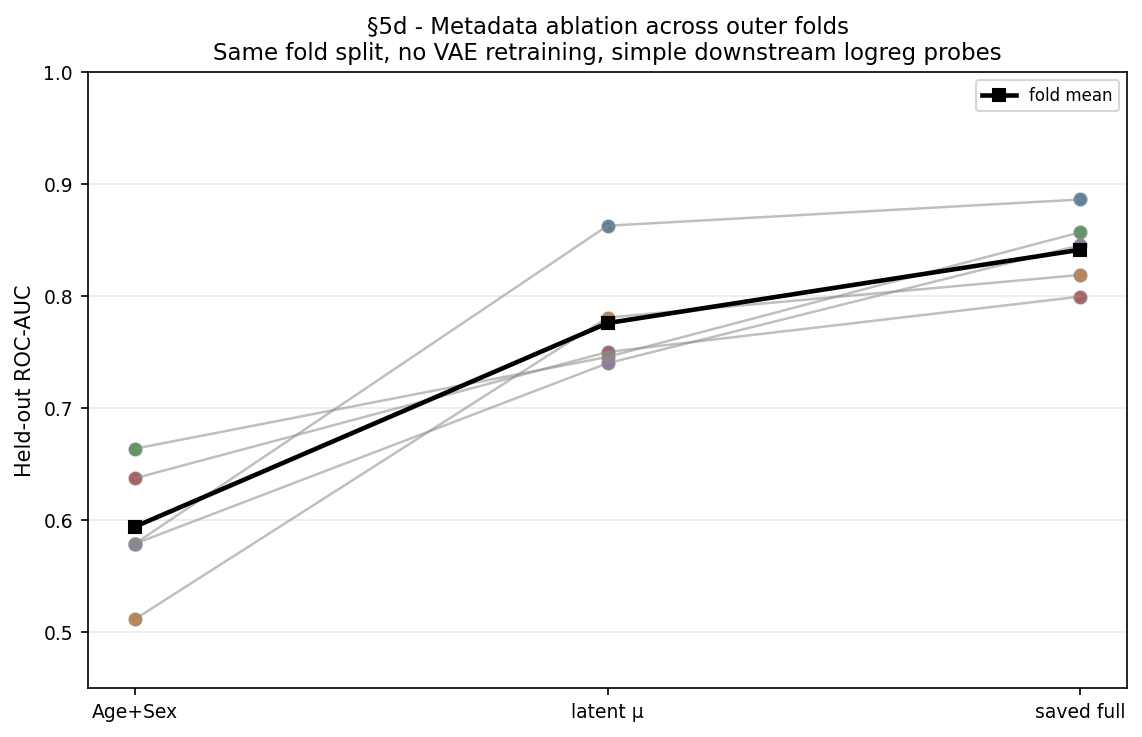

  [fig] 05d_metadata_ablation_slopes.png  [pdf] 05d_metadata_ablation_slopes.pdf
Metadata ablation summary (mean ± SD AUC across folds):
                  model    mean_pm_sd
  metadata_only_age_sex 0.594 ± 0.059
     connectome_only_mu 0.776 ± 0.051
full_pipeline_reference 0.841 ± 0.034

Interpretation:
  - Connectome-only clearly exceeds metadata-only across folds.
  - The saved full pipeline adds only a small increment over connectome-only.
  - In this run, that pattern is more consistent with genuine connectome signal in the diagnosis-agnostic latent code than with simple demographic confounding alone.


In [16]:
if not _REINFERENCE_AVAILABLE or META_BY_TIDX is None or GROUP_COL is None:
    print("[SKIP] §5d: requires re-inference and tensor-aligned metadata")
else:
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    def _make_ohe_dense():
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)

    ablation_rows = []
    score_priority = ["y_score_final", "y_score_cal", "y_score_raw"]

    folds_ablation = sorted(k for k in fold_mu_train_dict
                            if k in fold_mu_dict and k in fold_pred_paths and fold_pred_paths[k])
    for k in folds_ablation:
        train_idx = np.load(fold_train_tidx_paths[k]).astype(int)
        test_idx  = np.load(fold_test_tidx_paths[k]).astype(int)

        Z_tr = np.asarray(fold_mu_train_dict[k], float)
        Z_te = np.asarray(fold_mu_dict[k], float)
        y_tr = np.asarray(fold_y_train_dict.get(k, np.full(len(Z_tr), np.nan)), float)
        y_te = np.asarray(fold_y_dict.get(k, np.full(len(Z_te), np.nan)), float)
        mtr = ~np.isnan(y_tr)
        mte = ~np.isnan(y_te)

        fold_row = {
            "fold": int(k),
            "n_train": int(mtr.sum()),
            "n_test": int(mte.sum()),
            "n_AD_test": int((y_te[mte] == 1).sum()),
            "n_CN_test": int((y_te[mte] == 0).sum()),
        }

        if mtr.sum() >= 5 and mte.sum() >= 5 and len(np.unique(y_tr[mtr])) >= 2:
            pipe_mu = Pipeline([
                ("sc", StandardScaler()),
                ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
            ])
            pipe_mu.fit(Z_tr[mtr], y_tr[mtr].astype(int))
            fold_row["auc_connectome_mu_only"] = float(
                roc_auc_score(y_te[mte].astype(int), pipe_mu.predict_proba(Z_te[mte])[:, 1])
            )
        else:
            fold_row["auc_connectome_mu_only"] = np.nan

        X_meta_tr = META_BY_TIDX.reindex(train_idx)[["Age", "Sex"]].copy()
        X_meta_te = META_BY_TIDX.reindex(test_idx)[["Age", "Sex"]].copy()
        fold_row["n_missing_age_train"] = int(X_meta_tr["Age"].isna().sum())
        fold_row["n_missing_sex_train"] = int(X_meta_tr["Sex"].isna().sum())
        fold_row["n_missing_age_test"]  = int(X_meta_te["Age"].isna().sum())
        fold_row["n_missing_sex_test"]  = int(X_meta_te["Sex"].isna().sum())

        if mtr.sum() >= 5 and mte.sum() >= 5 and len(np.unique(y_tr[mtr])) >= 2:
            meta_pipe = Pipeline([
                ("pre", ColumnTransformer([
                    ("age", Pipeline([
                        ("imp", SimpleImputer(strategy="median")),
                        ("sc", StandardScaler()),
                    ]), ["Age"]),
                    ("sex", Pipeline([
                        ("imp", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _make_ohe_dense()),
                    ]), ["Sex"]),
                ], remainder="drop")),
                ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
            ])
            meta_pipe.fit(X_meta_tr.loc[mtr].reset_index(drop=True), y_tr[mtr].astype(int))
            fold_row["auc_metadata_age_sex_only"] = float(
                roc_auc_score(
                    y_te[mte].astype(int),
                    meta_pipe.predict_proba(X_meta_te.loc[mte].reset_index(drop=True))[:, 1],
                )
            )
        else:
            fold_row["auc_metadata_age_sex_only"] = np.nan

        pred_df = pd.read_csv(fold_pred_paths[k])
        score_col = next((c for c in score_priority if c in pred_df.columns), None)
        if score_col is None:
            fold_row["auc_full_pipeline_reference"] = np.nan
            fold_row["full_pipeline_score_source"] = "missing"
        else:
            fold_row["auc_full_pipeline_reference"] = float(
                roc_auc_score(pred_df["y_true"].astype(int), pred_df[score_col].astype(float))
            )
            fold_row["full_pipeline_score_source"] = score_col

        fold_row["delta_connectome_minus_metadata"] = (
            fold_row["auc_connectome_mu_only"] - fold_row["auc_metadata_age_sex_only"]
            if not np.isnan(fold_row["auc_connectome_mu_only"]) and not np.isnan(fold_row["auc_metadata_age_sex_only"])
            else np.nan
        )
        fold_row["delta_full_minus_connectome"] = (
            fold_row["auc_full_pipeline_reference"] - fold_row["auc_connectome_mu_only"]
            if not np.isnan(fold_row["auc_full_pipeline_reference"]) and not np.isnan(fold_row["auc_connectome_mu_only"])
            else np.nan
        )
        ablation_rows.append(fold_row)

    df_ablation_long = pd.DataFrame(ablation_rows)
    save_table(df_ablation_long, "05d_metadata_ablation_by_fold.csv")

    summary_rows = []
    for label, col in [
        ("metadata_only_age_sex", "auc_metadata_age_sex_only"),
        ("connectome_only_mu", "auc_connectome_mu_only"),
        ("full_pipeline_reference", "auc_full_pipeline_reference"),
    ]:
        vals = df_ablation_long[col].dropna().astype(float).values
        summary_rows.append({
            "model": label,
            "mean_auc": float(np.mean(vals)) if len(vals) else np.nan,
            "sd_auc": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "mean_pm_sd": f"{np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}" if len(vals) > 1 else (f"{np.mean(vals):.3f}" if len(vals) else "NA"),
            "n_folds": int(len(vals)),
        })
    df_ablation_summary = pd.DataFrame(summary_rows)
    save_table(df_ablation_summary, "05d_metadata_ablation_summary.csv")
    save_latex(
        df_ablation_summary,
        "05d_metadata_ablation_summary.csv",
        caption="Fold-wise metadata ablation for notebook 07. The connectome-only model uses latent $\\mu(x)$ only; the metadata-only model uses Age and Sex only; the saved full-pipeline reference uses the calibrated score from the original run.",
        label="tab:metadata_ablation",
    )

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    x_pos = np.arange(3)
    x_labels = ["Age+Sex", "latent μ", "saved full"]
    value_cols = ["auc_metadata_age_sex_only", "auc_connectome_mu_only", "auc_full_pipeline_reference"]
    for _, row in df_ablation_long.iterrows():
        vals = [row[c] for c in value_cols]
        ax.plot(x_pos, vals, marker="o", lw=1.2, alpha=0.55, color="0.55")
        ax.scatter(x_pos, vals, s=28)
    means = [df_ablation_long[c].mean() for c in value_cols]
    ax.plot(x_pos, means, color="black", lw=2.2, marker="s", ms=6, label="fold mean")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Held-out ROC-AUC")
    ax.set_ylim(0.45, 1.0)
    ax.set_title(
        "§5d - Metadata ablation across outer folds\n"
        "Same fold split, no VAE retraining, simple downstream logreg probes"
    )
    ax.grid(alpha=0.25, axis="y")
    ax.legend(fontsize=8)
    savefig("05d_metadata_ablation_slopes.png", fig)

    mu_mean   = df_ablation_summary.loc[df_ablation_summary["model"] == "connectome_only_mu", "mean_auc"].iloc[0]
    meta_mean = df_ablation_summary.loc[df_ablation_summary["model"] == "metadata_only_age_sex", "mean_auc"].iloc[0]
    full_mean = df_ablation_summary.loc[df_ablation_summary["model"] == "full_pipeline_reference", "mean_auc"].iloc[0]
    delta_mu_meta  = mu_mean - meta_mean
    delta_full_mu  = full_mean - mu_mean

    if delta_mu_meta >= 0.10:
        _interp_1 = "Connectome-only clearly exceeds metadata-only across folds."
    elif delta_mu_meta >= 0.03:
        _interp_1 = "Connectome-only exceeds metadata-only, but the gap is modest."
    else:
        _interp_1 = "Connectome-only does not clearly exceed metadata-only in this run."

    if delta_full_mu <= 0.08:
        _interp_2 = "The saved full pipeline adds only a small increment over connectome-only."
    else:
        _interp_2 = "The saved full pipeline adds a sizeable increment over connectome-only."

    print("Metadata ablation summary (mean ± SD AUC across folds):")
    print(df_ablation_summary[["model", "mean_pm_sd"]].to_string(index=False))
    print("\nInterpretation:")
    print(f"  - {_interp_1}")
    print(f"  - {_interp_2}")
    print("  - In this run, that pattern is more consistent with genuine connectome signal in the diagnosis-agnostic latent code than with simple demographic confounding alone.")


## §6 — Top-k Readout: Distributed vs Sparse Code  [Nested Clean + Per-Fold Uncertainty]

> **Protocol:**
> 1. **Ranking** is derived from *training-set* MI or logreg weights — never the test set.
> 2. A logistic regression is **fitted on training-set latents** for the top-k dimensions.
> 3. AUC is evaluated on the **held-out test fold** only.
>
> **Latent-only intent:** This section intentionally removes metadata features and studies
> how diagnostic information is distributed across latent `μ` itself. It therefore remains
> a native notebook-07 analysis even though the saved full pipeline also uses `Age` and `Sex`.
>
> **Why AUC values may be quantized:** With ~37 subjects per test fold and binary outcome,
> AUC values are inherently discretized. This is a consequence of small `N_test`, **not** a
> data processing artefact.
>
> **Primary ranking:** `by_w_abs` (logistic weight magnitude from the original pipeline).
>
> **Complement to notebook 04:** the broader purified-subspace / leakage trade-off analyses
> remain authoritative in notebook 04 (§19). Notebook 07 keeps the native top-k latent-only
> readout because it addresses the distinct distributed-vs-sparse coding question.
>
> **Interpretation:** Evidence is consistent with a **non-sparse / distributed
> representation** — AUC increases gradually with k across all strategies.
> The exact saturation point in k is uncertain given fold-level variance with small N_test.

In [17]:
if not _REINFERENCE_AVAILABLE or not _MI_AVAILABLE:
    print("[SKIP] §6: requires re-inference and train MI")
elif not any(k in fold_mu_train_dict for k in fold_mu_dict):
    print("[SKIP] §6: no folds with both train and test latents available")
else:
    from sklearn.linear_model import LogisticRegression as LR
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline as SkPipeline

    K_GRID = [k for k in [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128, 160, 192, 224, 256] if k <= LATENT_DIM]

    rank_strategy_specs = []

    # Primary strategy: by_w_abs only if §5b successfully extracted weights
    if ("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE and ("w_rank_order" in dir()) and (w_rank_order is not None):
        rank_strategy_specs.append({
            "strategy": "by_w_abs",
            "order": np.asarray(w_rank_order, dtype=int),
            "ranking_source": "saved raw logreg |w_k|",
            "available": True,
            "note": "Primary ranking from saved downstream raw logistic weights.",
        })
    else:
        print("[WARN] §6: by_w_abs omitted because §5b did not define a valid weight-based ranking.")

    # Train-only diagnostic MI
    rank_strategy_specs.append({
        "strategy": "by_mi_Y_train",
        "order": np.argsort(-mi_Y_nn),
        "ranking_source": "train-only marginal I(z_k;Y)",
        "available": True,
        "note": "Train-only marginal diagnostic MI ranking.",
    })

    # Heuristic MDR (explicitly non-canonical)
    rank_strategy_specs.append({
        "strategy": "by_heuristic_mdr_train",
        "order": np.argsort(-heuristic_mdr),
        "ranking_source": "train-only heuristic MDR",
        "available": True,
        "note": "Train-only heuristic marginal diagnostic ratio; marginal, non-canonical.",
    })

    df_rank_audit = pd.DataFrame([
        {
            "strategy": spec["strategy"],
            "ranking_source": spec["ranking_source"],
            "available": bool(spec["available"]),
            "n_ranked_dims": int(len(spec["order"])) if spec["order"] is not None else 0,
            "uses_test_information": False,
            "note": spec["note"],
        }
        for spec in rank_strategy_specs
    ])
    save_table(df_rank_audit, "06_ranking_strategy_audit.csv")

    folds_ok = sorted(
        k for k in fold_mu_train_dict
        if k in fold_mu_dict and k in fold_y_train_dict and k in fold_y_dict
    )
    print(f"Folds with both train+test latents: {folds_ok}")
    print(f"Ranking strategies used: {[spec['strategy'] for spec in rank_strategy_specs]}")

    long_rows = []
    for spec in rank_strategy_specs:
        strat = spec["strategy"]
        order = np.asarray(spec["order"], dtype=int)

        if order.ndim != 1 or len(order) < LATENT_DIM:
            raise ValueError(
                f"Ranking strategy {strat!r} returned invalid order with shape {order.shape}; expected at least {LATENT_DIM} dims."
            )

        for topk in K_GRID:
            dims = order[:topk]

            for k in folds_ok:
                Z_tr = fold_mu_train_dict[k][:, dims]
                y_tr = fold_y_train_dict[k]
                Z_te = fold_mu_dict[k][:, dims]
                y_te = fold_y_dict[k]

                mtr = ~np.isnan(y_tr)
                mte = ~np.isnan(y_te)

                n_tr = int(mtr.sum())
                n_te = int(mte.sum())
                n_ad_te = int((y_te[mte] == 1).sum())
                n_cn_te = int((y_te[mte] == 0).sum())

                row = {
                    "strategy": strat,
                    "ranking_source": spec["ranking_source"],
                    "k": int(topk),
                    "fold": int(k),
                    "n_train": n_tr,
                    "n_test": n_te,
                    "n_ad_test": n_ad_te,
                    "n_cn_test": n_cn_te,
                    "auc": np.nan,
                }

                if n_tr < 5 or n_te < 5 or len(np.unique(y_tr[mtr])) < 2:
                    long_rows.append(row)
                    continue

                Z_tr_c = Z_tr[mtr]
                y_tr_c = y_tr[mtr].astype(int)
                Z_te_c = Z_te[mte]
                y_te_c = y_te[mte].astype(int)

                pipe = SkPipeline([
                    ("sc", StandardScaler()),
                    ("lr", LR(max_iter=500, C=1.0, random_state=SEED)),
                ])

                try:
                    pipe.fit(Z_tr_c, y_tr_c)
                    auc_v = roc_auc_score(y_te_c, pipe.predict_proba(Z_te_c)[:, 1]) if len(np.unique(y_te_c)) >= 2 else np.nan
                    row["auc"] = float(auc_v) if not np.isnan(auc_v) else np.nan
                except Exception as e:
                    row["auc"] = np.nan
                    row["fit_error"] = str(e)

                long_rows.append(row)

    df_long = pd.DataFrame(long_rows)
    save_table(df_long, "06_topk_auc_by_strategy_by_fold.csv")
    print("[OK] §6 long table saved")

    _preview_strategy = "by_w_abs" if "by_w_abs" in df_long["strategy"].unique() else df_long["strategy"].iloc[0]
    print(f"\nPreview pivot for strategy={_preview_strategy!r}:")
    print(
        df_long[df_long["strategy"] == _preview_strategy]
        .pivot(index="k", columns="fold", values="auc")
        .round(3)
        .to_string()
    )

  [tbl] 06_ranking_strategy_audit.csv  (3 rows)
Folds with both train+test latents: [1, 2, 3, 4, 5]
Ranking strategies used: ['by_w_abs', 'by_mi_Y_train', 'by_heuristic_mdr_train']
  [tbl] 06_topk_auc_by_strategy_by_fold.csv  (225 rows)
[OK] §6 long table saved

Preview pivot for strategy='by_w_abs':
fold      1      2      3      4      5
k                                      
1     0.602  0.518  0.544  0.719  0.675
2     0.594  0.570  0.482  0.710  0.536
4     0.409  0.585  0.550  0.778  0.511
8     0.424  0.556  0.573  0.728  0.542
16    0.655  0.708  0.804  0.679  0.576
24    0.588  0.795  0.848  0.719  0.666
32    0.632  0.784  0.825  0.725  0.771
48    0.713  0.804  0.804  0.725  0.789
64    0.681  0.792  0.775  0.762  0.827
96    0.705  0.728  0.787  0.778  0.789
128   0.772  0.754  0.760  0.796  0.740
160   0.795  0.757  0.769  0.759  0.771
192   0.830  0.769  0.760  0.750  0.768
224   0.860  0.769  0.763  0.735  0.728
256   0.863  0.781  0.746  0.750  0.740


  [tbl] 06_topk_auc_by_strategy_nested_clean.csv  (15 rows)
  [tbl] 06_topk_auc_summary_long.csv  (45 rows)


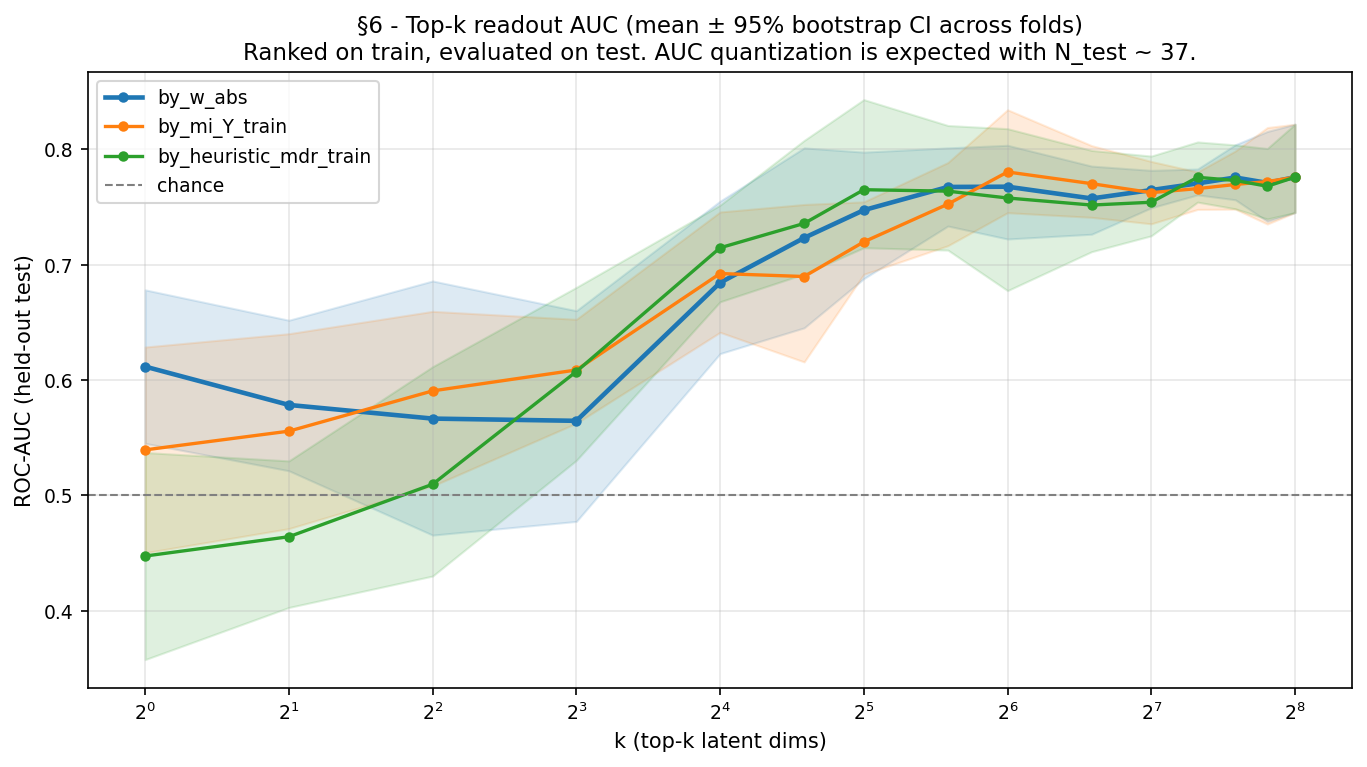

  [fig] 06_topk_readout_auc.png  [pdf] 06_topk_readout_auc.pdf
[OK] §6 done
  k  by_w_abs  by_mi_Y_train  by_heuristic_mdr_train
  1     0.612          0.539                   0.447
  2     0.578          0.556                   0.464
  4     0.566          0.591                   0.510
  8     0.565          0.609                   0.607
 16     0.684          0.692                   0.715
 24     0.723          0.690                   0.736
 32     0.747          0.720                   0.765
 48     0.767          0.752                   0.764
 64     0.768          0.780                   0.758
 96     0.757          0.770                   0.752
128     0.765          0.762                   0.754
160     0.770          0.766                   0.776
192     0.775          0.769                   0.773
224     0.771          0.772                   0.768
256     0.776          0.776                   0.776


In [18]:
if "df_long" not in dir():
    print("[SKIP] §6b: df_long not available")
else:
    if df_long.empty:
        print("[SKIP] §6b: df_long is empty")
    else:
        available_strategies = list(df_long["strategy"].dropna().unique())

        results_topk = {}
        results_lo = {}
        results_hi = {}
        results_std = {}
        summary_rows = []

        for strat in available_strategies:
            sub_s = df_long[df_long["strategy"] == strat]

            means_ = []
            los_ = []
            his_ = []
            stds_ = []

            for topk in K_GRID:
                aucs_ = sub_s[sub_s["k"] == topk]["auc"].dropna().astype(float).values
                n_non_nan = int(len(aucs_))

                if n_non_nan > 0:
                    m_ = float(np.mean(aucs_))
                    s_ = float(np.std(aucs_))
                else:
                    m_ = np.nan
                    s_ = np.nan

                if n_non_nan >= 2:
                    lo_, hi_ = bootstrap_ci(aucs_, n_boot=2000)
                else:
                    lo_, hi_ = m_, m_

                means_.append(m_)
                los_.append(lo_)
                his_.append(hi_)
                stds_.append(s_)

                summary_rows.append({
                    "strategy": strat,
                    "k": int(topk),
                    "mean_auc": m_,
                    "std_auc": s_,
                    "ci95_low": lo_,
                    "ci95_high": hi_,
                    "n_folds_non_nan": n_non_nan,
                })

            results_topk[strat] = means_
            results_lo[strat] = los_
            results_hi[strat] = his_
            results_std[strat] = stds_

        df_topk = pd.DataFrame({"k": K_GRID, **results_topk})
        df_topk_summary = pd.DataFrame(summary_rows)

        save_table(df_topk, "06_topk_auc_by_strategy_nested_clean.csv")
        save_table(df_topk_summary, "06_topk_auc_summary_long.csv")

        style_map = {
            "by_w_abs": {"color": "C0", "lw": 2.2, "label": "by_w_abs"},
            "by_mi_Y_train": {"color": "C1", "lw": 1.6, "label": "by_mi_Y_train"},
            "by_heuristic_mdr_train": {"color": "C2", "lw": 1.6, "label": "by_heuristic_mdr_train"},
        }

        fig, ax = plt.subplots(figsize=(9, 5))
        for strat in available_strategies:
            meta = style_map.get(strat, {"color": None, "lw": 1.5, "label": strat})
            ax.plot(
                K_GRID,
                results_topk[strat],
                marker="o",
                ms=4,
                lw=meta["lw"],
                label=meta["label"],
                color=meta["color"],
            )
            ax.fill_between(
                K_GRID,
                results_lo[strat],
                results_hi[strat],
                alpha=0.15,
                color=meta["color"],
            )

        ax.set_xscale("log", base=2)
        ax.set_xlabel("k (top-k latent dims)")
        ax.set_ylabel("ROC-AUC (held-out test)")
        ax.axhline(0.5, color="gray", lw=1, ls="--", label="chance")
        ax.set_title(
            "§6 - Top-k readout AUC (mean ± 95% bootstrap CI across folds)\n"
            "Ranked on train, evaluated on test. AUC quantization is expected with N_test ~ 37."
        )
        ax.legend()
        ax.grid(alpha=0.3)
        savefig("06_topk_readout_auc.png", fig)

        protocol_summary = {
            "ranking_data_split": "train_set_only (train_dev_tensor_idx.npy)",
            "evaluation_data_split": "held_out_test_fold (test_tensor_idx.npy)",
            "readout_model": "LogisticRegression(C=1)",
            "n_folds_used": int(len(folds_ok)) if "folds_ok" in dir() else None,
            "ranking_strategies_used": available_strategies,
            "weight_based_ranking_available": bool(("_WEIGHTS_AVAILABLE" in dir()) and _WEIGHTS_AVAILABLE),
            "k_grid": K_GRID,
            "uncertainty": "95% bootstrap CI across folds (2000 resamples)",
            "note_auc_quantization": (
                "With N_test ~ 37 per fold, AUC values are inherently discretized. "
                "This is expected and is not a processing artefact. "
                "Mean across folds reduces but does not eliminate quantization."
            ),
            "interpretation": (
                "Evidence is consistent with a distributed (non-sparse) representation. "
                "Exact saturation in k remains uncertain because fold-level test sets are small."
            ),
            "noncanonical_note": (
                "by_heuristic_mdr_train is based on the heuristic marginal diagnostic ratio, "
                "which is marginal and non-canonical; it should be interpreted as an exploratory ranking only."
            ),
        }
        with open(OUTPUT_DIR / "Tables" / "06_topk_protocol_summary.json", "w") as f:
            json.dump(protocol_summary, f, indent=2)

        print("[OK] §6 done")
        print(df_topk.round(3).to_string(index=False))

## §7 — Score-Level Information Theory and MaxEnt Readout

This section is intentionally narrower than notebook 04. Its target is the **score-level information-theoretic point**:

- the raw linear margin `m_raw`
- the calibrated logit `s_cal`
- the exact identity $H_\mathrm{raw} = h_2(\sigma(m_\mathrm{raw}))$
- why that identity does **not** survive post-hoc calibration

For the saved best logreg run analysed here, `m_raw` and `s_cal` come from the downstream CN/AD readout applied to its final feature vector (latent `μ` plus `Age` and `Sex` in this run). Full reliability diagrams, pooled calibration QC, ECE/Brier interpretation, and domain-specific calibration analyses remain authoritative in notebook 04 (§9).

### Explicit derivation: why the theoretical entropy curve applies only in Panel A

The logistic regression classifier defines the probability:
$$p_\mathrm{raw}(y=1\mid z) = \sigma(w^\top z + b)$$
The **raw linear margin** is uniquely determined by the classifier input:
$$m_\mathrm{raw} = w^\top z + b = \mathrm{logit}(p_\mathrm{raw})$$
The **predictive entropy** in bits is:
$$H_\mathrm{raw}(Y\mid z) = -p_\mathrm{raw}\log_2 p_\mathrm{raw} - (1-p_\mathrm{raw})\log_2(1-p_\mathrm{raw})
  = h_2\!\left(\sigma(m_\mathrm{raw})\right)$$
This is a **deterministic identity**: for any uncalibrated logistic regression, the entropy
is a fixed function of the margin $m_\mathrm{raw}$. Plotting $H$ vs $m_\mathrm{raw}$ must
exactly follow the theoretical curve $h_2(\sigma(m))$ up to numerical precision.

After calibration, the final probability $p_{\mathrm{cal}}$ is obtained by a separate mapping
(e.g. Platt scaling or isotonic regression) applied to the raw score. Therefore the final
calibrated score is no longer the original linear margin $m_{\mathrm{raw}} = w^\top x + b$.

However, if we define the calibrated logit as
$$
s_{\mathrm{cal}} = \mathrm{logit}(p_{\mathrm{cal}}),
$$
then the binary-entropy identity still holds by reparameterisation:
$$
H_{\mathrm{cal}}(Y\mid x)
= -p_{\mathrm{cal}}\log_2 p_{\mathrm{cal}} - (1-p_{\mathrm{cal}})\log_2(1-p_{\mathrm{cal}})
= h_2(\sigma(s_{\mathrm{cal}})).
$$

So the information-theoretic point is not that entropy ceases to be a deterministic function
of the calibrated logit. Rather, calibration breaks the direct identification between the final
score and the original raw linear margin of the logistic classifier.

Accordingly, §7 distinguishes two questions:

1. **Raw-score identity:** the uncalibrated margin $m_{\mathrm{raw}}$ obeys the exact logistic
   maximum-entropy geometry.
2. **Calibration warp:** post-hoc calibration changes the mapping from $m_{\mathrm{raw}}$ to the
   final decision score, and therefore changes confidence / entropy allocation across subjects.


| Score representation | Definition | Entropy identity | What is exact |
|---|---|---|---|
| $m_{\mathrm{raw}}$ | raw linear margin of the saved classifier | $H_{\mathrm{raw}} = h_2(\sigma(m_{\mathrm{raw}}))$ | exact raw logreg geometry |
| $s_{\mathrm{cal}}$ | calibrated logit $\mathrm{logit}(p_{\mathrm{cal}})$ | $H_{\mathrm{cal}} = h_2(\sigma(s_{\mathrm{cal}}))$ | exact by reparameterisation |
| calibration warp | mapping $m_{\mathrm{raw}} \mapsto s_{\mathrm{cal}}$ | no fixed identity from the original linear model | this is the actual post-hoc calibration effect |


In [19]:
preds_dfs = [pd.read_csv(p).assign(fold=k) for k,p in fold_pred_paths.items() if p and p.exists()]
_PREDS_AVAILABLE = bool(preds_dfs)
if not _PREDS_AVAILABLE:
    print("[SKIP] §7: no prediction CSVs found")
else:
    preds_all = pd.concat(preds_dfs, ignore_index=True)
    print(f"[OK] predictions: {len(preds_all)} rows  fold distribution:")
    print(dict(preds_all.groupby("fold")["y_true"].value_counts()))

[OK] predictions: 183 rows  fold distribution:
{(1, 1): 19, (1, 0): 18, (2, 1): 19, (2, 0): 18, (3, 1): 19, (3, 0): 18, (4, 0): 18, (4, 1): 18, (5, 1): 19, (5, 0): 17}


  [tbl] 07_per_fold_calibration_metrics.csv  (5 rows)
  [tex] 07_per_fold_calibration_metrics.tex
  [tbl] 07_entropy_margin_summary.csv  (2 rows)
  [tex] 07_entropy_margin_summary.tex
  [tbl] 07_group_score_geometry_summary.csv  (2 rows)
Per-fold score metrics (compact notebook-07 scope):
 fold  auc_raw  auc_cal  ece_raw  ece_cal  brier_raw  brier_cal  mean_H_raw_bits  mean_H_cal_bits
    1   0.8918   0.8860   0.1610   0.1785     0.1625     0.1616           0.8718           0.8940
    2   0.8246   0.8187   0.2060   0.1681     0.2131     0.1889           0.9711           0.8543
    3   0.8450   0.8567   0.1318   0.1929     0.1804     0.1652           0.9092           0.8433
    4   0.7994   0.7994   0.1884   0.1490     0.2330     0.2002           0.9951           0.8785
    5   0.8390   0.8452   0.1675   0.1937     0.2019     0.1843           0.9627           0.8977

Pooled score/entropy summary:
                           representation      auc      ece    brier  log_loss  mean_entrop

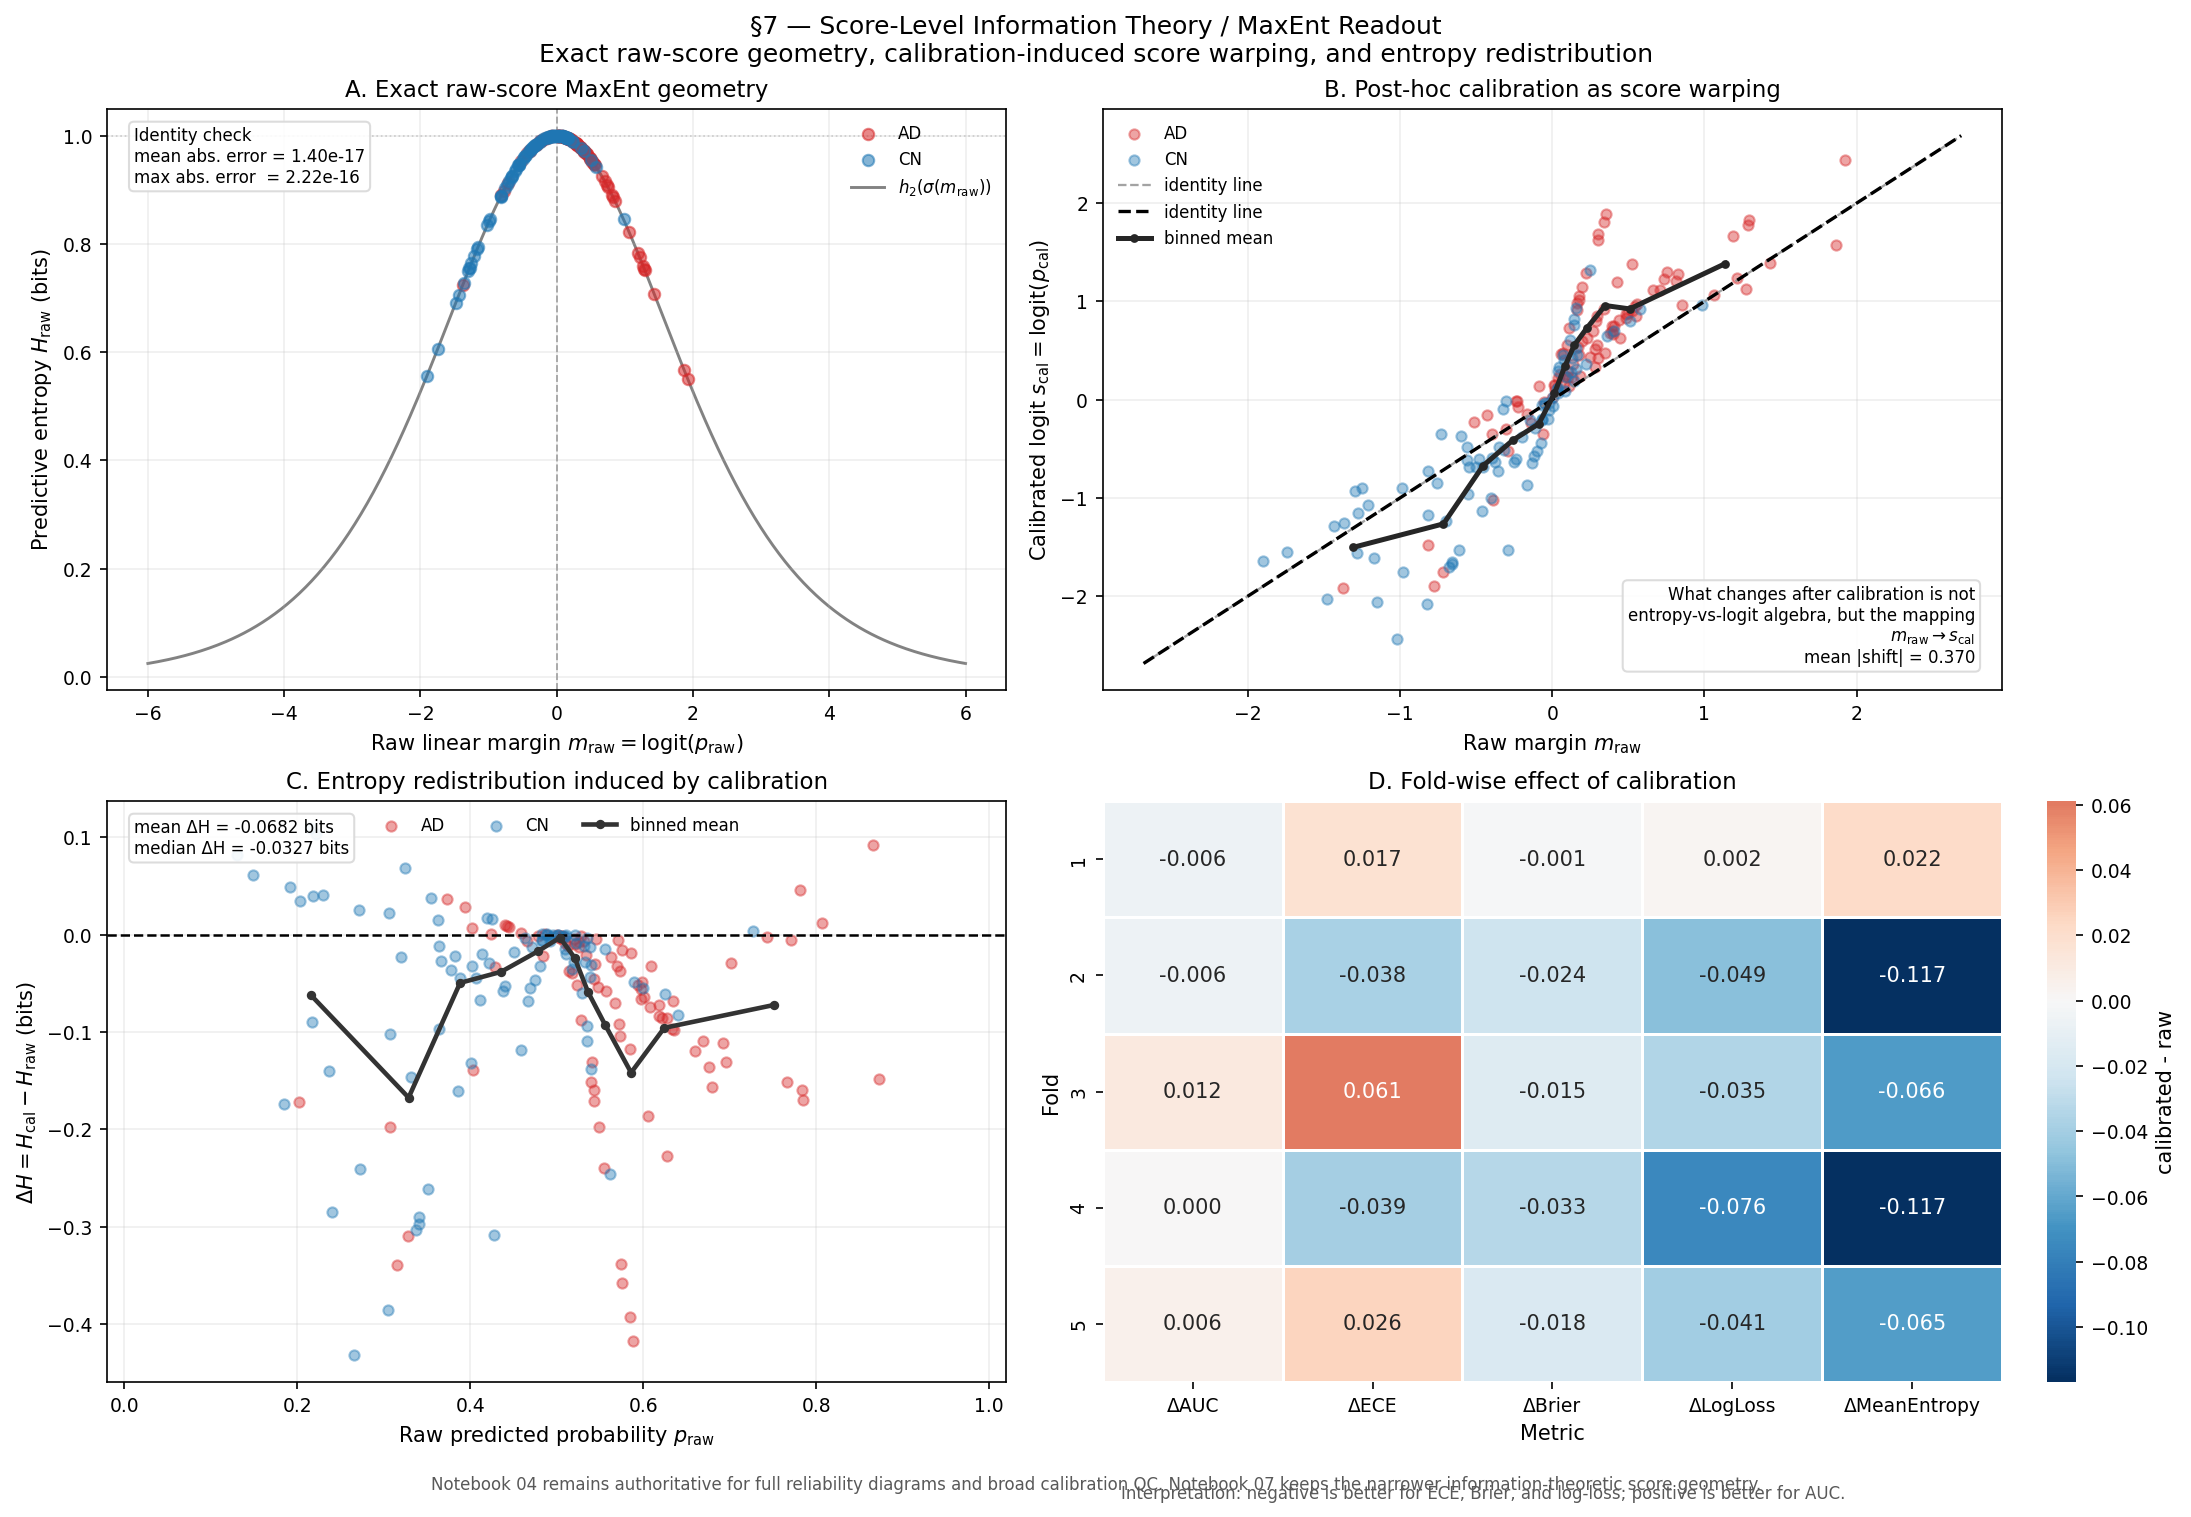

  [fig] 07_score_it_calibration.png  [pdf] 07_score_it_calibration.pdf
  [tbl] 07_score_level_entropy.csv  (183 rows)
[OK] §7 done


In [20]:
if not _PREDS_AVAILABLE:
    print("[SKIP] §7c")
else:
    preds_all = preds_all.copy()

    # ------------------------------------------------------------------
    # Score columns
    # ------------------------------------------------------------------
    if "y_score_raw" in preds_all.columns:
        preds_all["p_raw"] = preds_all["y_score_raw"].astype(float)
    elif "y_score_final" in preds_all.columns:
        preds_all["p_raw"] = preds_all["y_score_final"].astype(float)
    else:
        raise KeyError("§7 requires y_score_raw or y_score_final in the saved prediction CSVs")

    if "y_score_cal" in preds_all.columns:
        preds_all["p_cal"] = preds_all["y_score_cal"].astype(float)
    elif "y_score_final" in preds_all.columns:
        preds_all["p_cal"] = preds_all["y_score_final"].astype(float)
    else:
        preds_all["p_cal"] = preds_all["p_raw"]

    if "did_calibrate" in preds_all.columns:
        preds_all["did_calibrate"] = preds_all["did_calibrate"].fillna(False).astype(bool)
    else:
        preds_all["did_calibrate"] = (preds_all["p_cal"] - preds_all["p_raw"]).abs() > 1e-12

    preds_all["group"] = np.where(preds_all["y_true"].astype(int) == 1, "AD", "CN")

    def _logit_arr(p):
        p = np.clip(np.asarray(p, float), 1e-7, 1 - 1e-7)
        return np.log(p / (1 - p))

    preds_all["m_raw"] = _logit_arr(preds_all["p_raw"].astype(float))
    preds_all["s_cal"] = _logit_arr(preds_all["p_cal"].astype(float))

    preds_all["H_raw"] = bin_entropy_bits(preds_all["p_raw"].astype(float))
    preds_all["H_cal"] = bin_entropy_bits(preds_all["p_cal"].astype(float))

    # Exact entropy-vs-logit identities
    preds_all["H_from_m_raw"] = bin_entropy_bits(sigmoid(preds_all["m_raw"].astype(float)))
    preds_all["H_from_s_cal"] = bin_entropy_bits(sigmoid(preds_all["s_cal"].astype(float)))

    preds_all["raw_identity_abs_error"] = np.abs(preds_all["H_raw"] - preds_all["H_from_m_raw"])
    preds_all["cal_identity_abs_error"] = np.abs(preds_all["H_cal"] - preds_all["H_from_s_cal"])

    # Calibration-induced deformations
    preds_all["delta_p_cal_minus_raw"] = preds_all["p_cal"] - preds_all["p_raw"]
    preds_all["delta_s_cal_minus_m_raw"] = preds_all["s_cal"] - preds_all["m_raw"]
    preds_all["delta_H_cal_minus_raw"] = preds_all["H_cal"] - preds_all["H_raw"]

    # ------------------------------------------------------------------
    # Helper for smooth empirical trend lines
    # ------------------------------------------------------------------
    def _binned_mean_curve(x, y, q=12):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 8:
            return np.array([]), np.array([]), np.array([])

        x_m = x[mask]
        y_m = y[mask]
        q_eff = int(min(q, max(4, mask.sum() // 10)))
        if q_eff < 4:
            return np.array([]), np.array([]), np.array([])

        try:
            bins = pd.qcut(x_m, q=q_eff, duplicates="drop")
        except Exception:
            return np.array([]), np.array([]), np.array([])

        tmp = pd.DataFrame({"x": x_m, "y": y_m, "bin": bins})
        agg = (
            tmp.groupby("bin", observed=False)
            .agg(x_mean=("x", "mean"), y_mean=("y", "mean"), n=("y", "size"))
            .reset_index(drop=True)
        )
        return agg["x_mean"].values, agg["y_mean"].values, agg["n"].values

    # ------------------------------------------------------------------
    # Per-fold compact metrics
    # ------------------------------------------------------------------
    metric_rows = []
    for fold, sub in preds_all.groupby("fold"):
        yt = sub["y_true"].astype(int).values
        pr = sub["p_raw"].astype(float).values
        pc = sub["p_cal"].astype(float).values

        metr_raw = ece_brier(yt, pr)
        metr_cal = ece_brier(yt, pc)

        metric_rows.append({
            "fold": int(fold),
            "n_total": int(len(sub)),
            "n_AD": int((yt == 1).sum()),
            "n_CN": int((yt == 0).sum()),

            "auc_raw": float(roc_auc_score(yt, pr)),
            "auc_cal": float(roc_auc_score(yt, pc)),
            "auc_cal_minus_raw": float(roc_auc_score(yt, pc) - roc_auc_score(yt, pr)),

            "ece_raw": float(metr_raw["ece"]),
            "ece_cal": float(metr_cal["ece"]),
            "ece_cal_minus_raw": float(metr_cal["ece"] - metr_raw["ece"]),

            "brier_raw": float(metr_raw["brier"]),
            "brier_cal": float(metr_cal["brier"]),
            "brier_cal_minus_raw": float(metr_cal["brier"] - metr_raw["brier"]),

            "log_loss_raw": float(metr_raw["log_loss"]),
            "log_loss_cal": float(metr_cal["log_loss"]),
            "log_loss_cal_minus_raw": float(metr_cal["log_loss"] - metr_raw["log_loss"]),

            "mean_H_raw_bits": float(sub["H_raw"].mean()),
            "mean_H_cal_bits": float(sub["H_cal"].mean()),
            "mean_H_cal_minus_raw": float((sub["H_cal"] - sub["H_raw"]).mean()),

            "mean_abs_raw_margin": float(np.mean(np.abs(sub["m_raw"]))),
            "mean_abs_calibrated_logit": float(np.mean(np.abs(sub["s_cal"]))),
            "mean_abs_logit_shift": float(np.mean(np.abs(sub["delta_s_cal_minus_m_raw"]))),

            "mean_raw_identity_abs_error": float(sub["raw_identity_abs_error"].mean()),
            "max_raw_identity_abs_error": float(sub["raw_identity_abs_error"].max()),
            "mean_cal_identity_abs_error": float(sub["cal_identity_abs_error"].mean()),
            "max_cal_identity_abs_error": float(sub["cal_identity_abs_error"].max()),

            "did_any_calibration": bool(sub["did_calibrate"].any()),
        })

    df_score_metrics = pd.DataFrame(metric_rows).sort_values("fold").reset_index(drop=True)
    save_table(df_score_metrics, "07_per_fold_calibration_metrics.csv")
    save_latex(
        df_score_metrics.round(5),
        "07_per_fold_calibration_metrics.csv",
        caption=(
            "Compact per-fold score-level summary for notebook 07. "
            "Negative deltas indicate improvement for ECE, Brier, and log-loss; "
            "positive deltas indicate improvement for AUC."
        ),
        label="tab:score_level_metrics",
    )

    # ------------------------------------------------------------------
    # Pooled score/entropy summary (authoritative compact table for §7)
    # ------------------------------------------------------------------
    yt_all = preds_all["y_true"].astype(int).values
    pooled_raw = ece_brier(yt_all, preds_all["p_raw"].astype(float).values)
    pooled_cal = ece_brier(yt_all, preds_all["p_cal"].astype(float).values)

    df_entropy_summary = pd.DataFrame([
        {
            "representation": "raw_probability / raw_margin",
            "auc": float(roc_auc_score(yt_all, preds_all["p_raw"].astype(float).values)),
            "ece": float(pooled_raw["ece"]),
            "brier": float(pooled_raw["brier"]),
            "log_loss": float(pooled_raw["log_loss"]),
            "mean_probability": float(preds_all["p_raw"].mean()),
            "sd_probability": float(preds_all["p_raw"].std()),
            "mean_entropy_bits": float(preds_all["H_raw"].mean()),
            "sd_entropy_bits": float(preds_all["H_raw"].std()),
            "mean_abs_logit": float(np.mean(np.abs(preds_all["m_raw"]))),
            "mean_identity_abs_error": float(preds_all["raw_identity_abs_error"].mean()),
            "max_identity_abs_error": float(preds_all["raw_identity_abs_error"].max()),
        },
        {
            "representation": "calibrated_probability / calibrated_logit",
            "auc": float(roc_auc_score(yt_all, preds_all["p_cal"].astype(float).values)),
            "ece": float(pooled_cal["ece"]),
            "brier": float(pooled_cal["brier"]),
            "log_loss": float(pooled_cal["log_loss"]),
            "mean_probability": float(preds_all["p_cal"].mean()),
            "sd_probability": float(preds_all["p_cal"].std()),
            "mean_entropy_bits": float(preds_all["H_cal"].mean()),
            "sd_entropy_bits": float(preds_all["H_cal"].std()),
            "mean_abs_logit": float(np.mean(np.abs(preds_all["s_cal"]))),
            "mean_identity_abs_error": float(preds_all["cal_identity_abs_error"].mean()),
            "max_identity_abs_error": float(preds_all["cal_identity_abs_error"].max()),
        },
    ])
    save_table(df_entropy_summary, "07_entropy_margin_summary.csv")
    save_latex(
        df_entropy_summary.round(6),
        "07_entropy_margin_summary.csv",
        caption=(
            "Pooled score-level information summary. "
            "Because the notebook defines calibrated logits as $s_{cal}=\\mathrm{logit}(p_{cal})$, "
            "the entropy-logit identity also holds numerically in the calibrated representation."
        ),
        label="tab:entropy_margin_summary",
    )

    # ------------------------------------------------------------------
    # Optional group-wise geometry summary
    # ------------------------------------------------------------------
    group_rows = []
    for grp in ["CN", "AD"]:
        sub = preds_all[preds_all["group"] == grp]
        if len(sub) == 0:
            continue
        group_rows.append({
            "group": grp,
            "n": int(len(sub)),
            "mean_p_raw": float(sub["p_raw"].mean()),
            "mean_p_cal": float(sub["p_cal"].mean()),
            "mean_m_raw": float(sub["m_raw"].mean()),
            "mean_s_cal": float(sub["s_cal"].mean()),
            "mean_H_raw_bits": float(sub["H_raw"].mean()),
            "mean_H_cal_bits": float(sub["H_cal"].mean()),
            "mean_delta_H_cal_minus_raw": float(sub["delta_H_cal_minus_raw"].mean()),
            "mean_abs_logit_shift": float(np.mean(np.abs(sub["delta_s_cal_minus_m_raw"]))),
        })
    df_score_group = pd.DataFrame(group_rows)
    save_table(df_score_group, "07_group_score_geometry_summary.csv")

    print("Per-fold score metrics (compact notebook-07 scope):")
    print(df_score_metrics[[
        "fold", "auc_raw", "auc_cal", "ece_raw", "ece_cal",
        "brier_raw", "brier_cal", "mean_H_raw_bits", "mean_H_cal_bits"
    ]].round(4).to_string(index=False))

    print("\nPooled score/entropy summary:")
    print(df_entropy_summary[[
        "representation", "auc", "ece", "brier", "log_loss",
        "mean_entropy_bits", "mean_identity_abs_error", "max_identity_abs_error"
    ]].round(6).to_string(index=False))

    # ------------------------------------------------------------------
    # Figure: richer and conceptually correct §7 visual narrative
    # ------------------------------------------------------------------
    group = preds_all["group"].astype(str).to_numpy()
    m_raw = preds_all["m_raw"].astype(float).to_numpy()
    s_cal = preds_all["s_cal"].astype(float).to_numpy()
    p_raw = preds_all["p_raw"].astype(float).to_numpy()
    H_raw = preds_all["H_raw"].astype(float).to_numpy()
    H_cal = preds_all["H_cal"].astype(float).to_numpy()
    dH = preds_all["delta_H_cal_minus_raw"].astype(float).to_numpy()

    m_theory = np.linspace(-6, 6, 400)
    H_theory = bin_entropy_bits(sigmoid(m_theory))

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 10))
    axA, axB, axC, axD = axes.ravel()

    # Panel A — raw identity
    for lbl, color in PALETTE.items():
        if lbl == "MCI":
            continue
        idx_ = group == lbl
        axA.scatter(
            m_raw[idx_], H_raw[idx_],
            s=30, alpha=0.55, color=color, label=lbl, zorder=3
        )

    axA.plot(
        m_theory, H_theory,
        color="0.25", lw=1.4, alpha=0.65, zorder=1,
        label=r"$h_2(\sigma(m_{\mathrm{raw}}))$"
    )

    axA.axvline(0.0, color="0.65", lw=0.9, ls="--", zorder=0)
    axA.axhline(1.0, color="0.82", lw=0.8, ls=":", zorder=0)
    axA.set_xlabel(r"Raw linear margin $m_{\mathrm{raw}} = \mathrm{logit}(p_{\mathrm{raw}})$")
    axA.set_ylabel(r"Predictive entropy $H_{\mathrm{raw}}$ (bits)")
    axA.set_title("A. Exact raw-score MaxEnt geometry")
    axA.legend(frameon=False, fontsize=8, loc="upper right")
    axA.grid(alpha=0.20)
    axA.text(
        0.03, 0.97,
        "Identity check\n"
        f"mean abs. error = {preds_all['raw_identity_abs_error'].mean():.2e}\n"
        f"max abs. error  = {preds_all['raw_identity_abs_error'].max():.2e}",
        transform=axA.transAxes,
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.9),
    )

    # Panel B — calibration warp
    for lbl, color in PALETTE.items():
        if lbl == "MCI":
            continue
        idx_ = group == lbl
        axB.scatter(m_raw[idx_], s_cal[idx_], s=24, alpha=0.42, color=color, label=lbl)
    lim_min = min(np.nanmin(m_raw), np.nanmin(s_cal))
    lim_max = max(np.nanmax(m_raw), np.nanmax(s_cal))
    pad = 0.05 * (lim_max - lim_min + 1e-8)
    axB.plot(
        [lim_min - pad, lim_max + pad],
        [lim_min - pad, lim_max + pad],
        color="0.55", lw=1.1, ls="--", alpha=0.8,
        label="identity line"
    )


    axB.plot([lim_min - pad, lim_max + pad], [lim_min - pad, lim_max + pad],
             color="black", lw=1.6, ls="--", label="identity line")
    bx, by, bn = _binned_mean_curve(m_raw, s_cal, q=12)
    if len(bx):
        axB.plot(
            bx, by,
            color="0.15", lw=2.4, marker="o", ms=3.2,
            label="binned mean"
        )
    axB.set_xlabel(r"Raw margin $m_{\mathrm{raw}}$")
    axB.set_ylabel(r"Calibrated logit $s_{\mathrm{cal}} = \mathrm{logit}(p_{\mathrm{cal}})$")
    axB.set_title("B. Post-hoc calibration as score warping")
    axB.grid(alpha=0.20)
    axB.legend(frameon=False, fontsize=8, loc="upper left")
    axB.text(
            0.97, 0.04,  # Coordenadas cambiadas: casi al tope de la derecha (0.97) y bien abajo (0.04)
            "What changes after calibration is not\n"
            "entropy-vs-logit algebra, but the mapping\n"
            r"$m_{\mathrm{raw}} \rightarrow s_{\mathrm{cal}}$"
            "\n"
            f"mean |shift| = {np.mean(np.abs(preds_all['delta_s_cal_minus_m_raw'])):.3f}",
            transform=axB.transAxes,
            ha="right",  # Agregado: Ancla el texto a la derecha
            va="bottom", # Cambiado: Ancla el texto hacia abajo
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.9),
        )

    # Panel C — entropy shift
    for lbl, color in PALETTE.items():
        if lbl == "MCI":
            continue
        idx_ = group == lbl
        axC.scatter(p_raw[idx_], dH[idx_], s=24, alpha=0.42, color=color, label=lbl)
    axC.axhline(0.0, color="black", lw=1.2, ls="--")
    cx, cy, cn = _binned_mean_curve(p_raw, dH, q=12)
    if len(cx):
        axC.plot(cx, cy, color="0.2", lw=2.2, marker="o", ms=3.5, label="binned mean")
    axC.set_xlim(-0.02, 1.02)
    axC.set_xlabel(r"Raw predicted probability $p_{\mathrm{raw}}$")
    axC.set_ylabel(r"$\Delta H = H_{\mathrm{cal}} - H_{\mathrm{raw}}$ (bits)")
    axC.set_title("C. Entropy redistribution induced by calibration")
    axC.grid(alpha=0.20)
    axC.legend(frameon=False, fontsize=8, loc="upper center", ncol=3)
    axC.text(
        0.03, 0.97,
        f"mean ΔH = {preds_all['delta_H_cal_minus_raw'].mean():.4f} bits\n"
        f"median ΔH = {preds_all['delta_H_cal_minus_raw'].median():.4f} bits",
        transform=axC.transAxes,
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.9),
    )

    # Panel D — fold-wise delta heatmap
    delta_cols = [
        "auc_cal_minus_raw",
        "ece_cal_minus_raw",
        "brier_cal_minus_raw",
        "log_loss_cal_minus_raw",
        "mean_H_cal_minus_raw",
    ]
    delta_panel = (
        df_score_metrics.set_index("fold")[delta_cols]
        .rename(columns={
            "auc_cal_minus_raw": "ΔAUC",
            "ece_cal_minus_raw": "ΔECE",
            "brier_cal_minus_raw": "ΔBrier",
            "log_loss_cal_minus_raw": "ΔLogLoss",
            "mean_H_cal_minus_raw": "ΔMeanEntropy",
        })
    )
    sns.heatmap(
        delta_panel,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "calibrated - raw"},
        ax=axD,
    )
    axD.set_title("D. Fold-wise effect of calibration")
    axD.set_xlabel("Metric")
    axD.set_ylabel("Fold")
    axD.text(
        0.02, -0.20,
        "Interpretation: negative is better for ECE, Brier, and log-loss; positive is better for AUC.",
        transform=axD.transAxes,
        fontsize=8,
        color="0.35",
    )

    fig.suptitle(
        "§7 — Score-Level Information Theory / MaxEnt Readout\n"
        "Exact raw-score geometry, calibration-induced score warping, and entropy redistribution",
        fontsize=12,
    )

    fig.text(
        0.5, 0.01,
        "Notebook 04 remains authoritative for full reliability diagrams and broad calibration QC. "
        "Notebook 07 keeps the narrower information-theoretic score geometry.",
        ha="center",
        va="bottom",
        fontsize=8,
        color="0.35",
    )

    savefig("07_score_it_calibration.png", fig)

    cols_out = [c for c in [
        "fold", "SubjectID", "tensor_idx", "group", "y_true",
        "y_score_raw", "y_score_cal", "y_score_final",
        "p_raw", "p_cal",
        "m_raw", "s_cal",
        "H_raw", "H_cal",
        "H_from_m_raw", "H_from_s_cal",
        "raw_identity_abs_error", "cal_identity_abs_error",
        "delta_p_cal_minus_raw", "delta_s_cal_minus_m_raw", "delta_H_cal_minus_raw",
        "y_pred", "did_calibrate"
    ] if c in preds_all.columns]
    save_table(preds_all[cols_out], "07_score_level_entropy.csv")

    print("[OK] §7 done")